# IT504 Assignment 3 — CBIS-DDSM Breast Cancer Classification

**Comparative Analysis of Classical ML Models for Medical Image Classification**

This notebook trains and compares four machine learning algorithms on the CBIS-DDSM breast cancer dataset:

1. Support Vector Machine (SVM)  
2. Decision Tree  
3. Random Forest  
4. Naive Bayes  

The classification task is converted into a binary problem:

- **0 = Benign**
- **1 = Malignant**

The notebook includes dataset loading, preprocessing, feature extraction, model training, evaluation, visualization, uploaded-image testing, and approximate suspicious-region visualization.

> **Important:** This notebook is for academic experimentation only. It is not a medical diagnostic tool.

## 1. Install Required Packages

Run this once at the beginning of the Colab session.

In [ ]:
!pip install -q kaggle opencv-python scikit-image scikit-learn matplotlib pandas numpy tqdm joblib

## 2. Kaggle Setup and Dataset Download

Upload your `kaggle.json` file when prompted. If the dataset is already downloaded, this cell will not unzip it again.

In [ ]:
import os
from pathlib import Path
from google.colab import files

DATASET_DIR = Path('/content/cbis_ddsm')
ZIP_NAME = 'cbis-ddsm-breast-cancer-image-dataset.zip'

if not Path('/content/kaggle.json').exists() and not Path('/root/.kaggle/kaggle.json').exists():
    print('Please upload kaggle.json')
    files.upload()

Path('/root/.kaggle').mkdir(parents=True, exist_ok=True)
if Path('/content/kaggle.json').exists():
    !cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if not Path(ZIP_NAME).exists():
    !kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
else:
    print('Dataset zip already exists.')

if not DATASET_DIR.exists():
    !unzip -q cbis-ddsm-breast-cancer-image-dataset.zip -d cbis_ddsm
else:
    print('Dataset folder already exists.')

Please upload kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:48<00:00, 111MB/s]



## 3. Imports and Configuration

`FEATURE_MODE` controls the feature extraction method:

- `raw`: grayscale + resize + normalize + flatten
- `hog`: CLAHE + HOG shape/edge features

For better F1-score, start with `FEATURE_MODE = "hog"`.

In [ ]:
import os
import re
import glob
import random
from pathlib import Path
from collections import defaultdict

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

RANDOM_STATE = 42
BASE_PATH = Path('/content/cbis_ddsm')
CSV_PATH = BASE_PATH / 'csv'
JPEG_PATH = BASE_PATH / 'jpeg'

FEATURE_MODE = 'hog'   # change to 'raw' if you want the simpler baseline
RAW_IMG_SIZE = 64
HOG_IMG_SIZE = 128

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 4. Load All Four CSV Files

This uses both **mass** and **calcification** cases:

- `mass_case_description_train_set.csv`
- `mass_case_description_test_set.csv`
- `calc_case_description_train_set.csv`
- `calc_case_description_test_set.csv`

In [ ]:
mass_train = pd.read_csv(CSV_PATH / 'mass_case_description_train_set.csv')
mass_test = pd.read_csv(CSV_PATH / 'mass_case_description_test_set.csv')
calc_train = pd.read_csv(CSV_PATH / 'calc_case_description_train_set.csv')
calc_test = pd.read_csv(CSV_PATH / 'calc_case_description_test_set.csv')

mass_train['case_type'] = 'mass'
mass_test['case_type'] = 'mass'
calc_train['case_type'] = 'calcification'
calc_test['case_type'] = 'calcification'

train_df = pd.concat([mass_train, calc_train], ignore_index=True)
test_df = pd.concat([mass_test, calc_test], ignore_index=True)

print('Mass train:', mass_train.shape)
print('Mass test:', mass_test.shape)
print('Calcification train:', calc_train.shape)
print('Calcification test:', calc_test.shape)
print('Combined train:', train_df.shape)
print('Combined test:', test_df.shape)

Mass train: (1318, 15)
Mass test: (378, 15)
Calcification train: (1546, 15)
Calcification test: (326, 15)
Combined train: (2864, 18)
Combined test: (704, 18)


## 5. Dataset Summary

These tables are useful for the **Dataset Description** slide.

In [ ]:
print('Train pathology distribution:')
print(train_df['pathology'].value_counts())

print('Test pathology distribution:')
print(test_df['pathology'].value_counts())

print('Train case type distribution:')
print(train_df['case_type'].value_counts())

print('Test case type distribution:')
print(test_df['case_type'].value_counts())

train_df.head()

Train pathology distribution:
pathology
MALIGNANT                  1181
BENIGN                     1105
BENIGN_WITHOUT_CALLBACK     578
Name: count, dtype: int64
Test pathology distribution:
pathology
BENIGN                     324
MALIGNANT                  276
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64
Train case type distribution:
case_type
calcification    1546
mass             1318
Name: count, dtype: int64
Test case type distribution:
case_type
mass             378
calcification    326
Name: count, dtype: int64


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,case_type,breast density,calc type,calc distribution
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,mass,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,mass,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,mass,NaN,NaN,NaN


## 6. Match CSV Image Paths to JPEG Files

The CSV uses DICOM-style paths, while Kaggle provides converted JPEG folders. The matching is done using the UID numbers inside the paths.

In [ ]:
real_files = [f for f in glob.glob(str(JPEG_PATH / '**/*'), recursive=True) if os.path.isfile(f)]
print('Number of real image files:', len(real_files))
print('Example file:', real_files[0] if real_files else 'No files found')

uid_pattern = r'1\.3\.6\.1\.4\.1\.9590[.\d]+'
uid_to_files = defaultdict(list)

for file_path in real_files:
    uids = re.findall(uid_pattern, file_path)
    for uid in uids:
        uid_to_files[uid].append(file_path)

print('Number of unique UIDs mapped:', len(uid_to_files))

def find_matching_image(csv_image_path):
    uids = re.findall(uid_pattern, str(csv_image_path))
    for uid in reversed(uids):
        if uid in uid_to_files and len(uid_to_files[uid]) > 0:
            return uid_to_files[uid][0]
    return None

train_df['matched_image_path'] = train_df['cropped image file path'].apply(find_matching_image)
test_df['matched_image_path'] = test_df['cropped image file path'].apply(find_matching_image)

print('Train matched:', train_df['matched_image_path'].notna().sum(), '/', len(train_df))
print('Test matched:', test_df['matched_image_path'].notna().sum(), '/', len(test_df))

Number of real image files: 10237
Example file: /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.397606830411615017608398463122497867206/1-014.jpg
Number of unique UIDs mapped: 6774
Train matched: 2863 / 2864
Test matched: 704 / 704


## 7. Clean Dataset and Encode Labels

Pathology labels are mapped as:

- `MALIGNANT` → `1`
- `BENIGN` and `BENIGN_WITHOUT_CALLBACK` → `0`

In [ ]:
def encode_pathology(label):
    return 1 if str(label).strip().upper() == 'MALIGNANT' else 0

train_clean = train_df.dropna(subset=['matched_image_path']).copy()
test_clean = test_df.dropna(subset=['matched_image_path']).copy()

train_clean['label'] = train_clean['pathology'].apply(encode_pathology)
test_clean['label'] = test_clean['pathology'].apply(encode_pathology)

print('Clean train shape:', train_clean.shape)
print('Clean test shape:', test_clean.shape)

print('Binary labels — train:')
print(train_clean['label'].value_counts().rename({0: 'Benign', 1: 'Malignant'}))

print('Binary labels — test:')
print(test_clean['label'].value_counts().rename({0: 'Benign', 1: 'Malignant'}))

Clean train shape: (2863, 20)
Clean test shape: (704, 20)
Binary labels — train:
label
Benign       1682
Malignant    1181
Name: count, dtype: int64
Binary labels — test:
label
Benign       428
Malignant    276
Name: count, dtype: int64


## 8. Visualize Sample Images

This cell shows a few random cropped abnormality images.

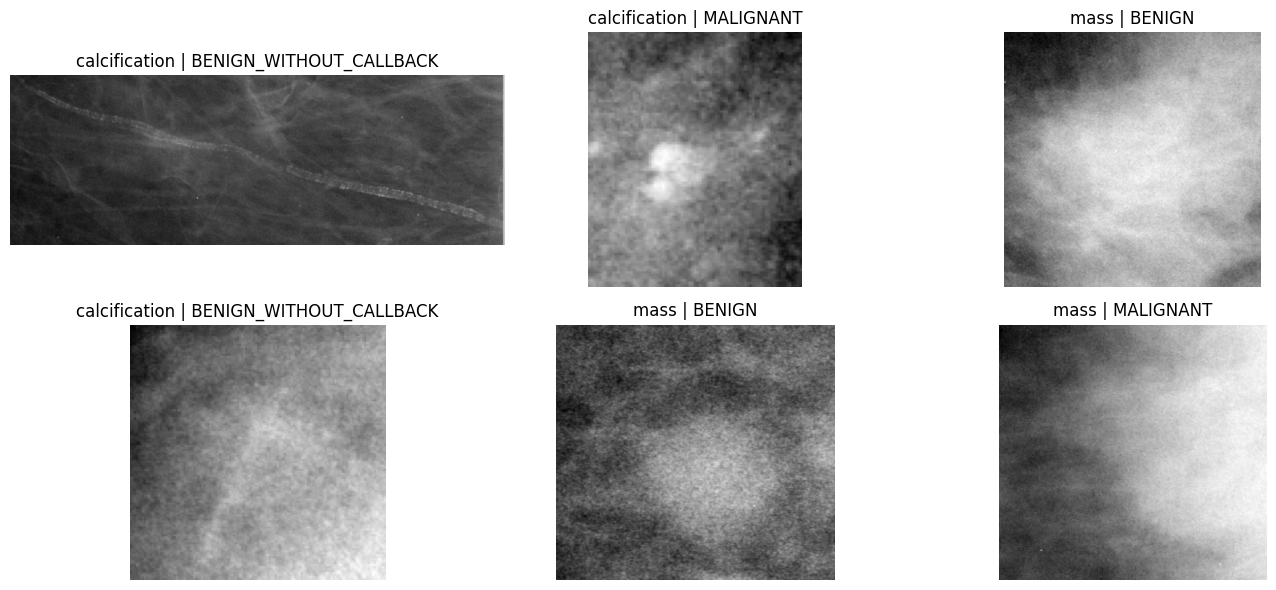

In [ ]:
def show_random_samples(df, n=6):
    sample_df = df.sample(min(n, len(df)), random_state=RANDOM_STATE)
    plt.figure(figsize=(14, 6))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row['matched_image_path'], cv2.IMREAD_GRAYSCALE)
        plt.subplot(2, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(f"{row['case_type']} | {row['pathology']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_samples(train_clean, n=6)

## 9. Feature Extraction

Two feature strategies are supported:

### Raw Pixel Baseline
Image → grayscale → resize to 64×64 → normalize → flatten

### Improved HOG Pipeline
Image → grayscale → resize to 128×128 → CLAHE contrast enhancement → normalize → HOG features

HOG usually helps classical ML models because it captures edge and shape information instead of using only raw pixels.

In [ ]:
def extract_features_from_gray(gray_image):
    if FEATURE_MODE == 'raw':
        resized = cv2.resize(gray_image, (RAW_IMG_SIZE, RAW_IMG_SIZE))
        normalized = resized / 255.0
        return normalized.flatten()

    if FEATURE_MODE == 'hog':
        resized = cv2.resize(gray_image, (HOG_IMG_SIZE, HOG_IMG_SIZE))
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(resized)
        normalized = enhanced / 255.0
        features = hog(
            normalized,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        return features

    raise ValueError("FEATURE_MODE must be either 'raw' or 'hog'")


def extract_features_from_path(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    return extract_features_from_gray(image)


def build_feature_dataset(df):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        features = extract_features_from_path(row['matched_image_path'])
        if features is not None:
            X.append(features)
            y.append(row['label'])
    return np.array(X), np.array(y)

print('Feature mode:', FEATURE_MODE)

Feature mode: hog


## 10. Build Train, Validation, and Test Sets

A validation set is created from the training data. It is used to tune the decision threshold for F1-score. The official test set remains untouched until final evaluation.

In [ ]:
X_train_full, y_train_full = build_feature_dataset(train_clean)
X_test, y_test = build_feature_dataset(test_clean)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)
print('y_test:', y_test.shape)

100%|██████████| 704/704 [00:10<00:00, 69.68it/s]

X_train: (2290, 1764)
X_val: (573, 1764)
X_test: (704, 1764)
y_train: (2290,)
y_val: (573,)
y_test: (704,)


## 11. Train Four ML Models

Class balancing is used where supported because medical datasets can have class imbalance.

In [ ]:
models = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            C=3,
            gamma='scale',
            probability=True,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Naive Bayes': GaussianNB(var_smoothing=1e-8)
}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    print(f'{name} trained successfully.')

Training SVM...
SVM trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Random Forest...
Random Forest trained successfully.
Training Naive Bayes...
Naive Bayes trained successfully.


## 12. Threshold Tuning for F1-Score

The default threshold is 0.50. To improve F1-score, this notebook selects the threshold that gives the best F1-score on the validation set.

In [ ]:
def get_positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def find_best_threshold(model, X_val, y_val):
    scores = get_positive_scores(model, X_val)
    best_threshold = 0.50
    best_f1 = -1
    for threshold in np.arange(0.10, 0.91, 0.01):
        preds = (scores >= threshold).astype(int)
        score = f1_score(y_val, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    return float(best_threshold), float(best_f1)

thresholds = {}
for name, model in models.items():
    threshold, val_f1 = find_best_threshold(model, X_val, y_val)
    thresholds[name] = threshold
    print(f'{name}: best threshold = {threshold:.2f}, validation F1 = {val_f1:.3f}')

SVM: best threshold = 0.32, validation F1 = 0.606
Decision Tree: best threshold = 0.10, validation F1 = 0.539
Random Forest: best threshold = 0.38, validation F1 = 0.626
Naive Bayes: best threshold = 0.10, validation F1 = 0.492


## 13. Final Evaluation on Test Set

The table reports performance after applying the validation-selected threshold.

In [ ]:
def evaluate_model(model, X, y, threshold=0.50):
    scores = get_positive_scores(model, X)
    preds = (scores >= threshold).astype(int)
    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1-score': f1_score(y, preds, zero_division=0),
        'AUC': roc_auc_score(y, scores)
    }

results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test, thresholds[name])

results_df = pd.DataFrame(results).T.sort_values('F1-score', ascending=False)
results_df

,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Random Forest,0.38,0.500000,0.431900,0.873188,0.577938,0.602029
SVM,0.32,0.455966,0.409475,0.876812,0.558247,0.589966
Decision Tree,0.10,0.457386,0.399621,0.764493,0.524876,0.512448
Naive Bayes,0.10,0.518466,0.408696,0.510870,0.454106,0.544503


## 14. Performance Bar Chart

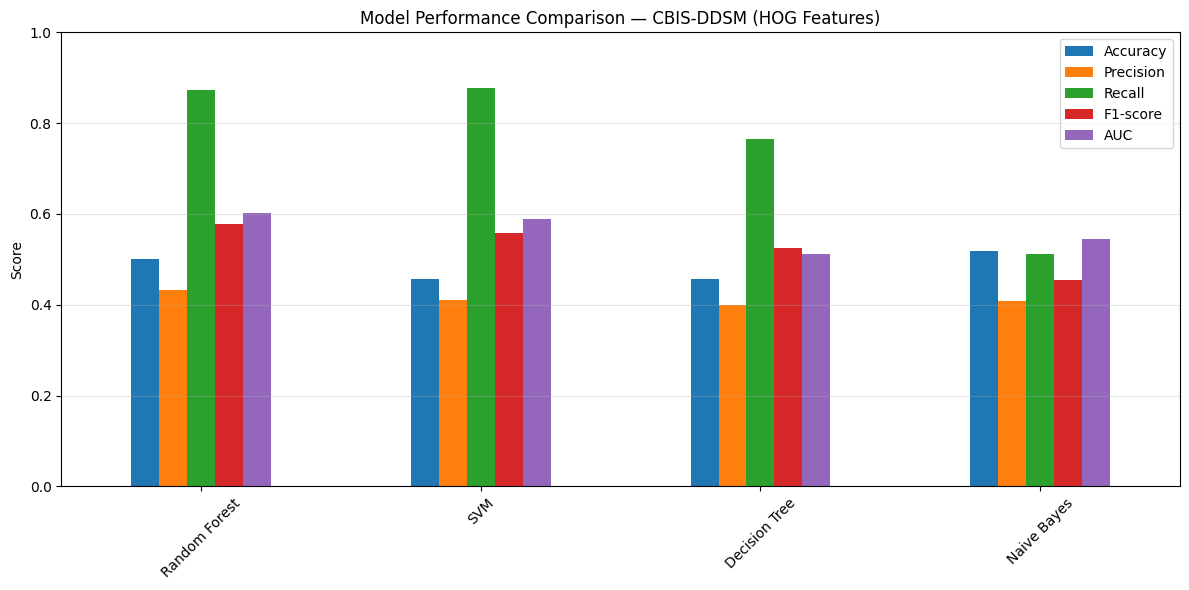

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6))
plt.title(f'Model Performance Comparison — CBIS-DDSM ({FEATURE_MODE.upper()} Features)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Confusion Matrices

False negatives are especially important in breast cancer classification because they represent malignant cases predicted as benign.

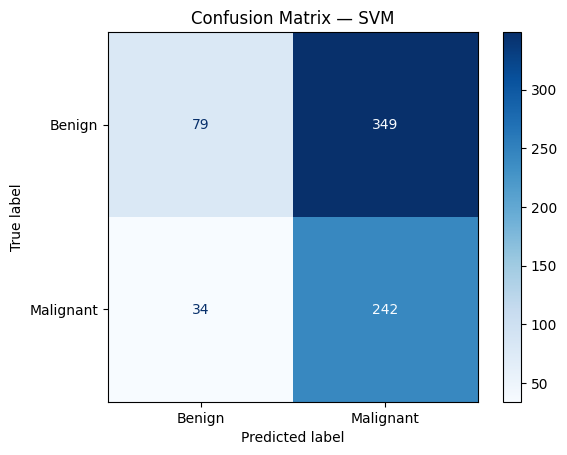

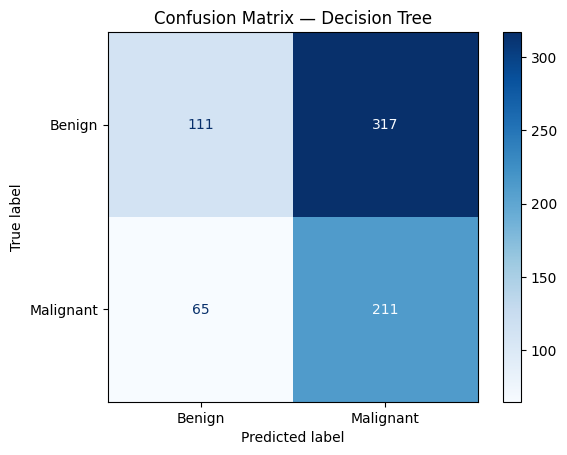

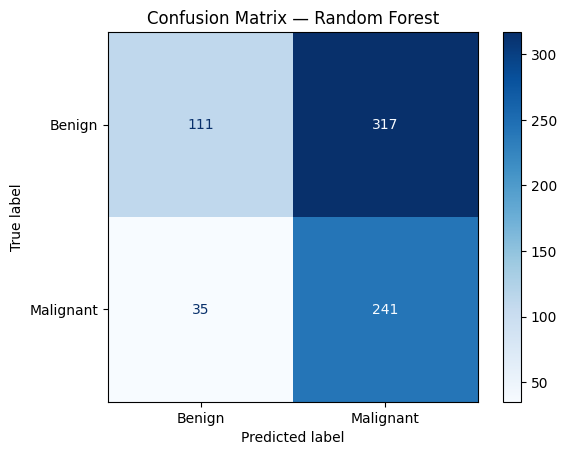

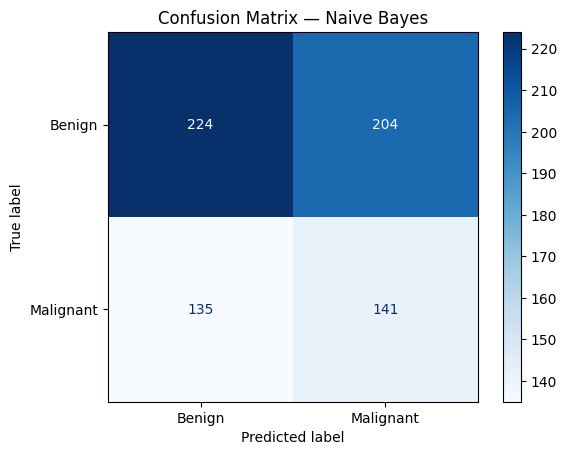

In [ ]:
for name, model in models.items():
    scores = get_positive_scores(model, X_test)
    preds = (scores >= thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

## 16. ROC Curve Comparison

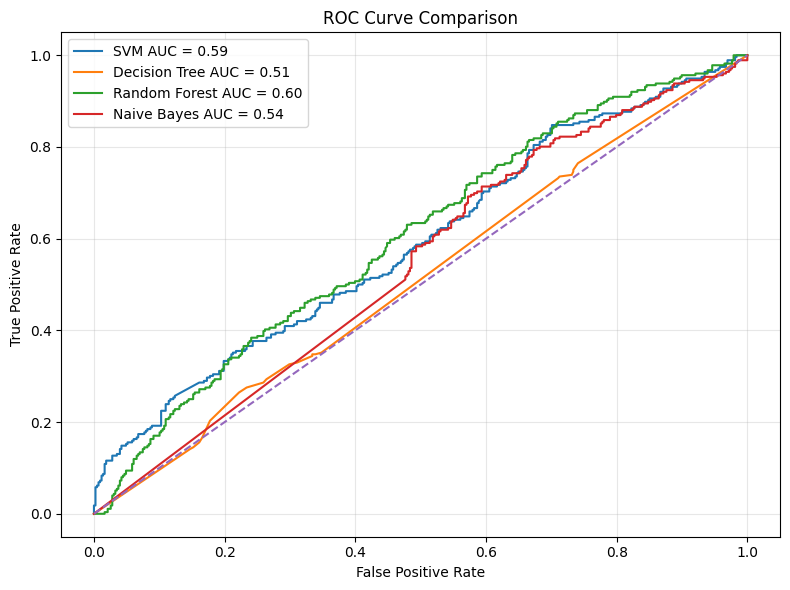

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    scores = get_positive_scores(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} AUC = {roc_auc:.2f}')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Precision-Recall Curve Comparison

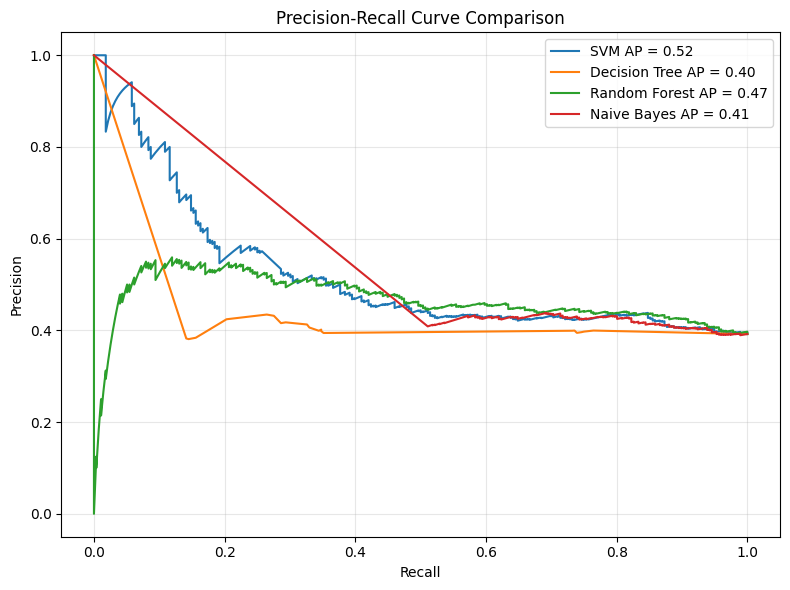

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    scores = get_positive_scores(model, X_test)
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.plot(recall, precision, label=f'{name} AP = {ap:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Save Models and Results

This saves the trained models, thresholds, feature mode, and results table.

In [ ]:
artifact = {
    'models': models,
    'thresholds': thresholds,
    'feature_mode': FEATURE_MODE,
    'raw_img_size': RAW_IMG_SIZE,
    'hog_img_size': HOG_IMG_SIZE,
    'results_df': results_df,
}

joblib.dump(artifact, '/content/cbis_ddsm_ml_artifact.joblib')
results_df.to_csv('/content/cbis_ddsm_results.csv')

print('Saved: /content/cbis_ddsm_ml_artifact.joblib')
print('Saved: /content/cbis_ddsm_results.csv')

Saved: /content/cbis_ddsm_ml_artifact.joblib
Saved: /content/cbis_ddsm_results.csv


## 19. Upload or Select an Image for Demo

You can either upload a new image or choose a random test image.

Randomly selected image:
Path: /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.88158044112350000736236683583018260323/1-002.jpg
True label: Benign
Case type: mass
Original pathology: BENIGN


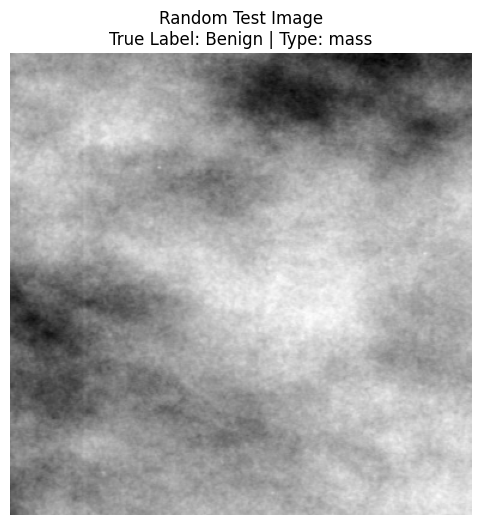

In [ ]:
USE_RANDOM_TEST_IMAGE = True  # change to False to upload your own image

if USE_RANDOM_TEST_IMAGE:
   random_row = test_clean.sample(n=1, random_state=None).iloc[0]

   uploaded_image_path = random_row["matched_image_path"]
   selected_true_label = "Malignant" if random_row["label"] == 1 else "Benign"
   selected_case_type = random_row["case_type"]
   selected_pathology = random_row["pathology"]

   print("Randomly selected image:")
   print("Path:", uploaded_image_path)
   print("True label:", selected_true_label)
   print("Case type:", selected_case_type)
   print("Original pathology:", selected_pathology)

    # Display selected image
   image = cv2.imread(uploaded_image_path, cv2.IMREAD_GRAYSCALE)

   plt.figure(figsize=(6, 6))
   plt.imshow(image, cmap="gray")
   plt.title(f"Random Test Image\nTrue Label: {selected_true_label} | Type: {selected_case_type}")
   plt.axis("off")
   plt.show()
else:
    uploaded = files.upload()
    uploaded_image_path = list(uploaded.keys())[0]
    print('Uploaded image:', uploaded_image_path)

## 20. Show Image Processing Steps

This visualization follows the same feature pipeline used by the trained models.

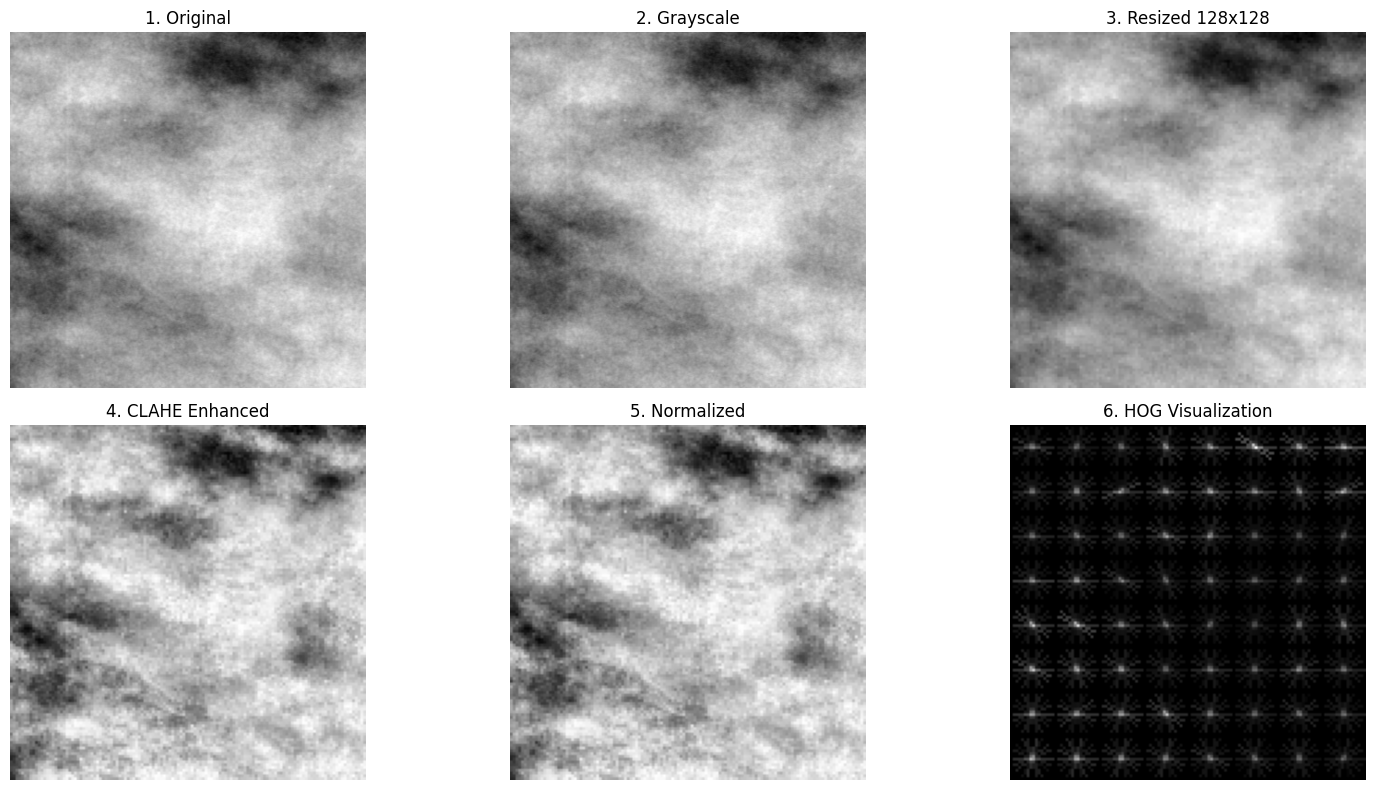

Demo feature shape: (1, 1764)
Training feature shape: (2290, 1764)


In [ ]:
def show_processing_steps(image_path):
    original = cv2.imread(str(image_path))
    if original is None:
        raise ValueError('Image could not be loaded.')

    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    if FEATURE_MODE == 'raw':
        resized = cv2.resize(gray, (RAW_IMG_SIZE, RAW_IMG_SIZE))
        normalized = resized / 255.0

        plt.figure(figsize=(14, 4))
        plt.subplot(1, 4, 1); plt.imshow(original_rgb); plt.title('1. Original'); plt.axis('off')
        plt.subplot(1, 4, 2); plt.imshow(gray, cmap='gray'); plt.title('2. Grayscale'); plt.axis('off')
        plt.subplot(1, 4, 3); plt.imshow(resized, cmap='gray'); plt.title(f'3. Resized {RAW_IMG_SIZE}x{RAW_IMG_SIZE}'); plt.axis('off')
        plt.subplot(1, 4, 4); plt.imshow(normalized, cmap='gray'); plt.title('4. Normalized'); plt.axis('off')
        plt.tight_layout(); plt.show()
    else:
        resized = cv2.resize(gray, (HOG_IMG_SIZE, HOG_IMG_SIZE))
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(resized)
        normalized = enhanced / 255.0
        hog_features, hog_image = hog(
            normalized,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=True
        )

        plt.figure(figsize=(16, 8))
        plt.subplot(2, 3, 1); plt.imshow(original_rgb); plt.title('1. Original'); plt.axis('off')
        plt.subplot(2, 3, 2); plt.imshow(gray, cmap='gray'); plt.title('2. Grayscale'); plt.axis('off')
        plt.subplot(2, 3, 3); plt.imshow(resized, cmap='gray'); plt.title(f'3. Resized {HOG_IMG_SIZE}x{HOG_IMG_SIZE}'); plt.axis('off')
        plt.subplot(2, 3, 4); plt.imshow(enhanced, cmap='gray'); plt.title('4. CLAHE Enhanced'); plt.axis('off')
        plt.subplot(2, 3, 5); plt.imshow(normalized, cmap='gray'); plt.title('5. Normalized'); plt.axis('off')
        plt.subplot(2, 3, 6); plt.imshow(hog_image, cmap='gray'); plt.title('6. HOG Visualization'); plt.axis('off')
        plt.tight_layout(); plt.show()

    features = extract_features_from_path(image_path).reshape(1, -1)
    print('Demo feature shape:', features.shape)
    print('Training feature shape:', X_train.shape)
    return features

demo_features = show_processing_steps(uploaded_image_path)

## 21. Predict Uploaded/Test Image with All Models

In [ ]:
def predict_single_image(features):
    rows = []
    for name, model in models.items():
        prob_malignant = get_positive_scores(model, features)[0]
        threshold = thresholds[name]
        prediction = int(prob_malignant >= threshold)
        rows.append({
            'Model': name,
            'Threshold': threshold,
            'Prediction': 'Malignant' if prediction == 1 else 'Benign',
            'Benign Probability': 1 - prob_malignant,
            'Malignant Probability': prob_malignant,
        })
    return pd.DataFrame(rows)

prediction_results = predict_single_image(demo_features)
prediction_results

,Model,Threshold,Prediction,Benign Probability,Malignant Probability
0,SVM,0.32,Malignant,0.532560,4.674402e-01
1,Decision Tree,0.10,Malignant,0.737561,2.624390e-01
2,Random Forest,0.38,Malignant,0.571540,4.284601e-01
3,Naive Bayes,0.10,Benign,1.000000,9.213351e-41


## 22. Show Model Predictions on the Image

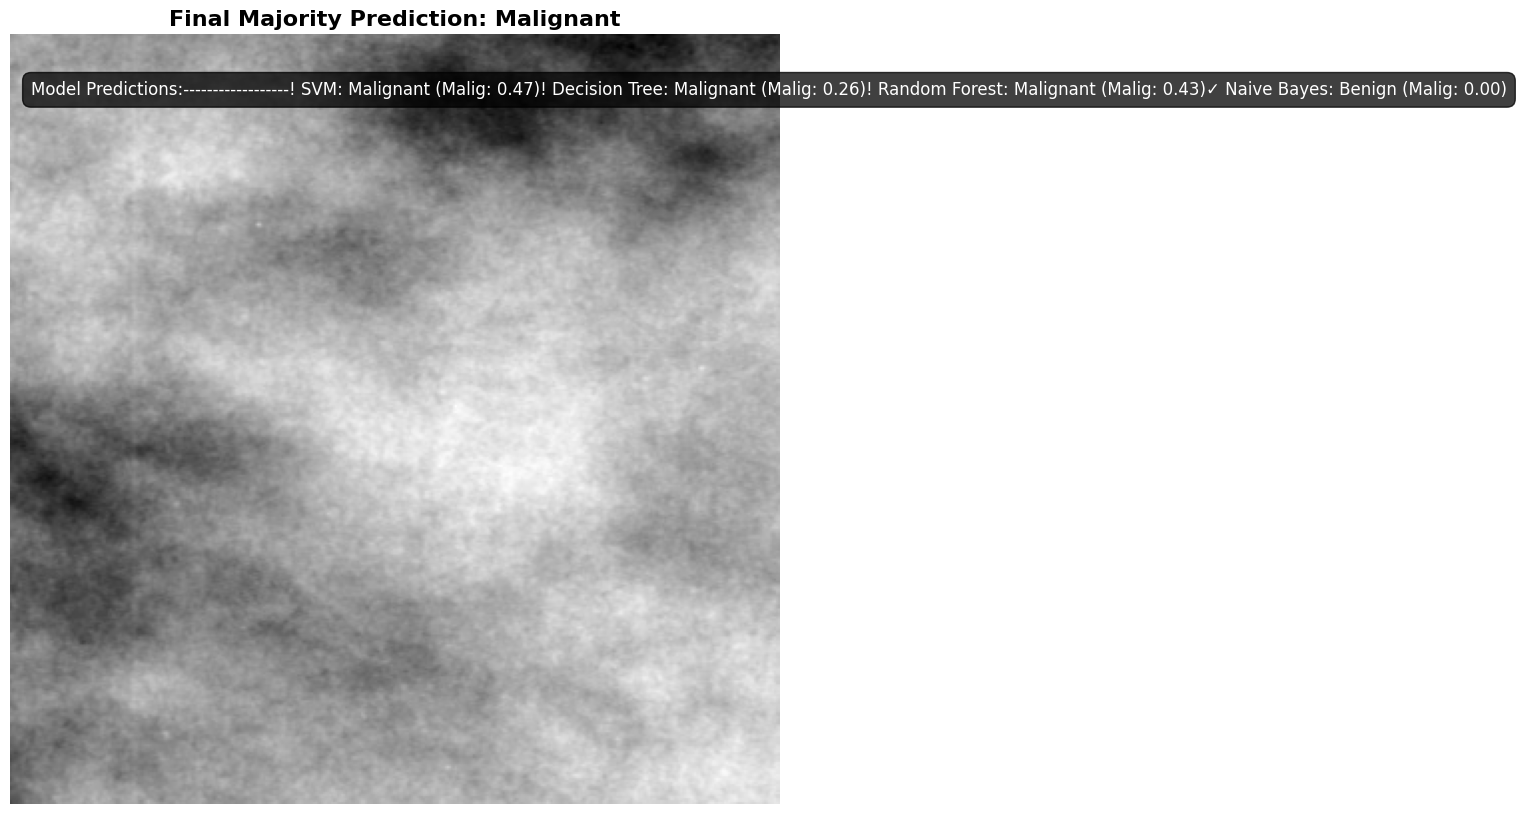

Final majority prediction: Malignant


In [ ]:
def show_prediction_on_image(image_path, prediction_results):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError('Could not load image.')

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    malignant_count = (prediction_results['Prediction'] == 'Malignant').sum()
    benign_count = (prediction_results['Prediction'] == 'Benign').sum()

    if malignant_count > benign_count:
        final_prediction = 'Malignant'
    elif benign_count > malignant_count:
        final_prediction = 'Benign'
    else:
        final_prediction = 'Tie / Uncertain'

    lines = ['Model Predictions:', '------------------']
    for _, row in prediction_results.iterrows():
        marker = '!' if row['Prediction'] == 'Malignant' else '✓'
        lines.append(f"{marker} {row['Model']}: {row['Prediction']} (Malig: {row['Malignant Probability']:.2f})")

    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(f'Final Majority Prediction: {final_prediction}', fontsize=16, fontweight='bold')
    plt.text(
        10,
        30,
        ''.join(lines),
        fontsize=12,
        color='white',
        bbox=dict(facecolor='black', alpha=0.75, boxstyle='round,pad=0.5')
    )
    plt.show()
    return final_prediction

final_prediction = show_prediction_on_image(uploaded_image_path, prediction_results)
print('Final majority prediction:', final_prediction)

## 23. Approximate Suspicious Region Visualization

This uses **occlusion sensitivity**. Small image patches are hidden one by one. If hiding a patch reduces the malignant probability, that patch is considered important and highlighted in red.

This is an approximate explanation method, **not true medical segmentation**.

Showing suspicious area for: SVM


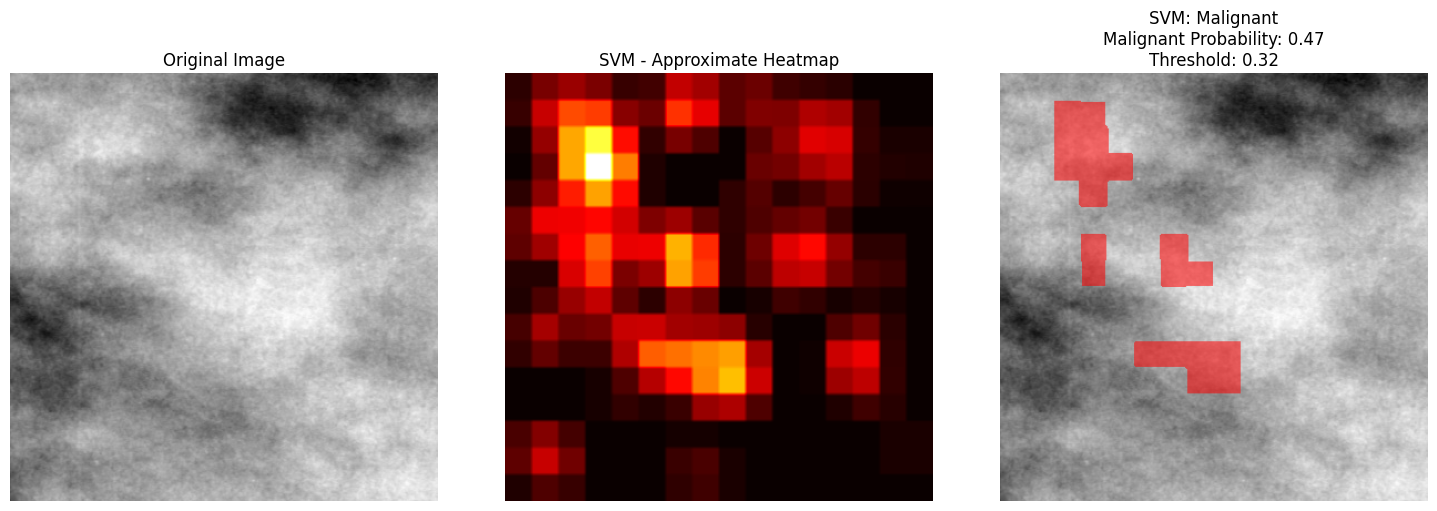

Showing suspicious area for: Decision Tree


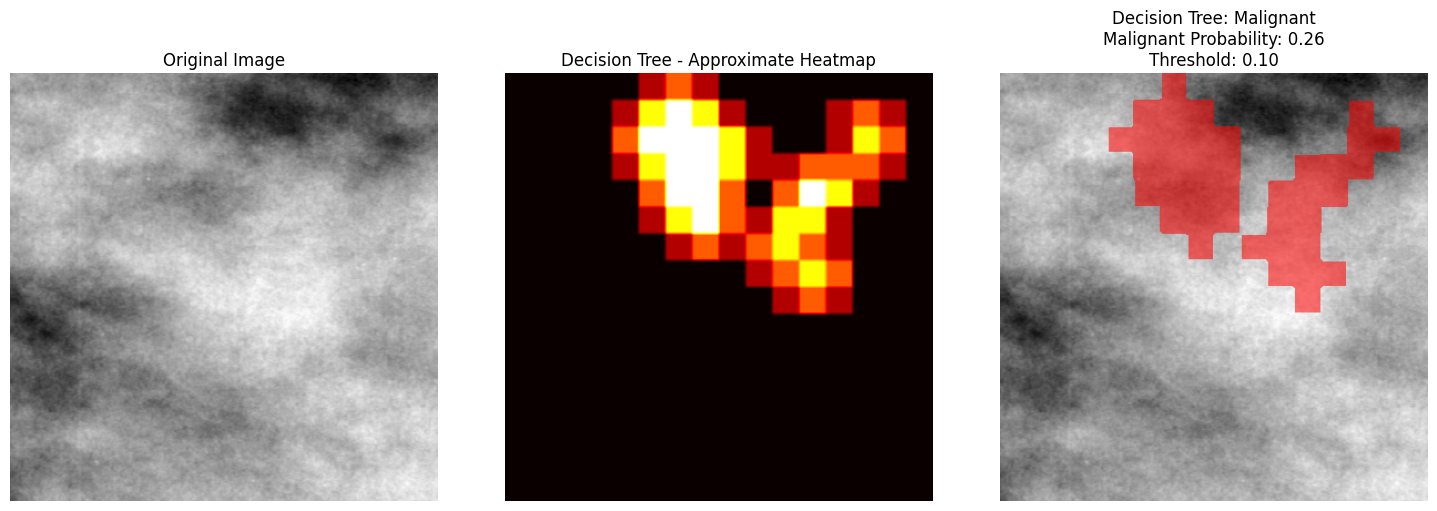

Showing suspicious area for: Random Forest


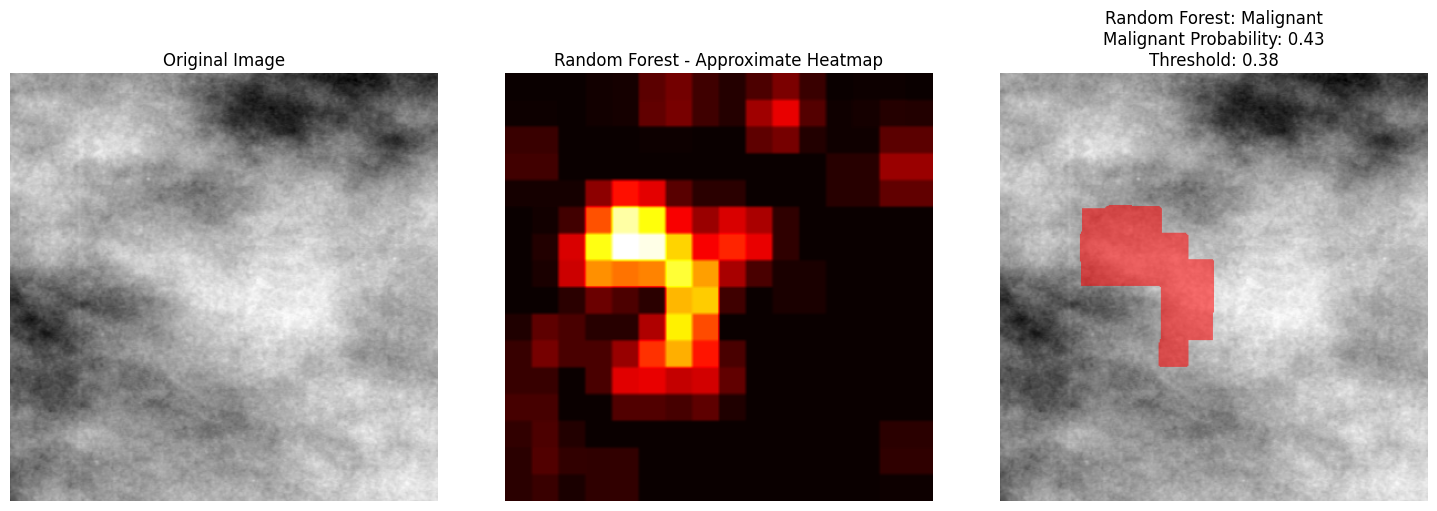

Showing suspicious area for: Naive Bayes


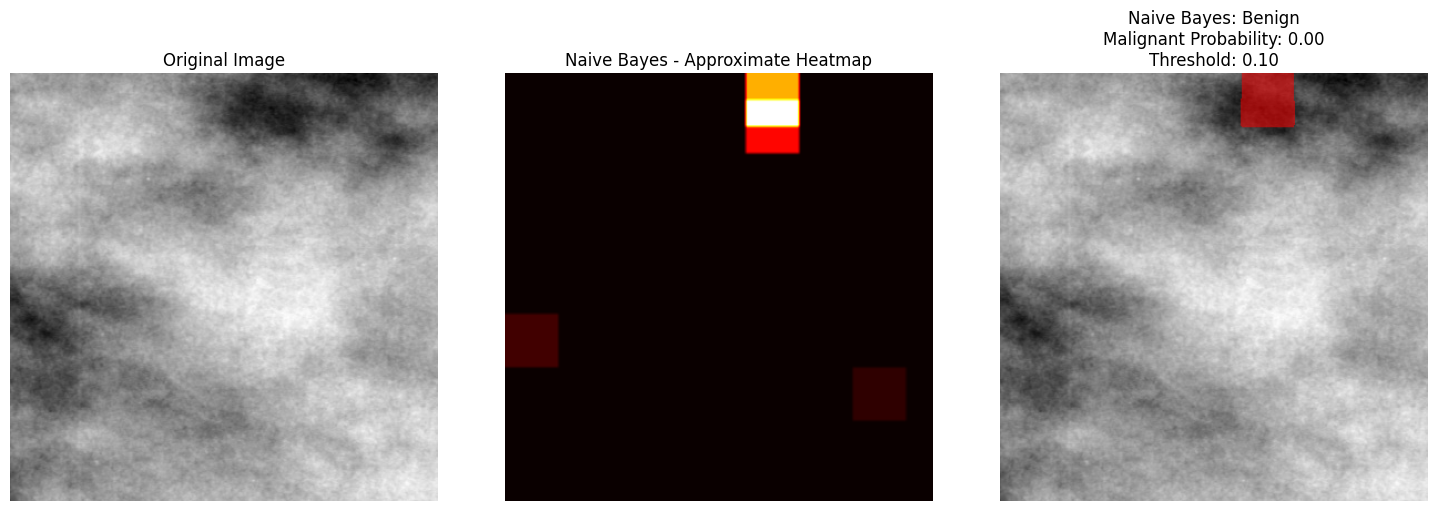

,Model,Prediction,Malignant Probability,Threshold
0,SVM,Malignant,4.674402e-01,0.32
1,Decision Tree,Malignant,2.624390e-01,0.10
2,Random Forest,Malignant,4.284601e-01,0.38
3,Naive Bayes,Benign,9.213351e-41,0.10


In [ ]:
def create_occlusion_heatmap(image_path, model, patch_size=16, stride=8):
    original = cv2.imread(str(image_path))
    if original is None:
        raise ValueError("Could not load image.")

    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    heatmap_size = HOG_IMG_SIZE if FEATURE_MODE == "hog" else RAW_IMG_SIZE
    gray_resized = cv2.resize(gray, (heatmap_size, heatmap_size))

    original_features = extract_features_from_gray(gray_resized).reshape(1, -1)
    original_prob = get_positive_scores(model, original_features)[0]

    heatmap = np.zeros((heatmap_size, heatmap_size), dtype=np.float32)

    for y in range(0, heatmap_size - patch_size + 1, stride):
        for x in range(0, heatmap_size - patch_size + 1, stride):
            occluded = gray_resized.copy()
            occluded[y:y + patch_size, x:x + patch_size] = 0

            features = extract_features_from_gray(occluded).reshape(1, -1)
            new_prob = get_positive_scores(model, features)[0]

            importance = original_prob - new_prob

            if importance > 0:
                heatmap[y:y + patch_size, x:x + patch_size] += importance

    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return original_rgb, heatmap, original_prob


def show_red_suspicious_area(image_path, model_name, threshold_value=0.45):
    model = models[model_name]

    original_rgb, heatmap, original_prob = create_occlusion_heatmap(
        image_path=image_path,
        model=model,
        patch_size=16,
        stride=8
    )

    h, w, _ = original_rgb.shape
    heatmap_large = cv2.resize(heatmap, (w, h))

    red_overlay = np.zeros_like(original_rgb)
    red_overlay[:, :, 0] = 255

    mask = heatmap_large > threshold_value

    highlighted = original_rgb.copy()
    blended = cv2.addWeighted(original_rgb, 0.45, red_overlay, 0.55, 0)
    highlighted[mask] = blended[mask]

    model_threshold = thresholds.get(model_name, 0.5)
    prediction = "Malignant" if original_prob >= model_threshold else "Benign"

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_large, cmap="hot")
    plt.title(f"{model_name} - Approximate Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(highlighted)
    plt.title(
        f"{model_name}: {prediction}\n"
        f"Malignant Probability: {original_prob:.2f}\n"
        f"Threshold: {model_threshold:.2f}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Prediction": prediction,
        "Malignant Probability": original_prob,
        "Threshold": model_threshold
    }


all_results = []

for model_name in models.keys():
    print(f"Showing suspicious area for: {model_name}")

    result = show_red_suspicious_area(
        image_path=uploaded_image_path,
        model_name=model_name,
        threshold_value=0.45
    )

    all_results.append(result)

all_model_explanations = pd.DataFrame(all_results)
all_model_explanations

## 24. Conclusion

The experiment compared four classical machine learning algorithms for binary breast cancer classification using the CBIS-DDSM dataset. Both mass and calcification cases were included to increase dataset coverage. Cropped abnormality images were used because they focus on the region of interest.

The preprocessing pipeline converted each image to grayscale, enhanced contrast using CLAHE, and extracted HOG features to capture edge and shape information. Class balancing and threshold tuning were used to improve F1-score, which is important because the F1-score balances precision and recall.

In breast cancer classification, recall is especially important because a false negative means a malignant case is predicted as benign. Therefore, the best model should not be selected based only on accuracy, but also based on recall, F1-score, AUC, and the number of false negatives.

The red suspicious-region visualization is based on occlusion sensitivity. It shows which image regions influenced the model’s malignant prediction, but it is not a medical segmentation result.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# ============================================================
# 1. Helper: get malignant/positive score from any model
# ============================================================

def get_positive_scores(model, X):
    """
    Returns probability/score for class 1 = Malignant.
    Works with models that have predict_proba or decision_function.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    else:
        return model.predict(X)


# ============================================================
# 2. Calculate validation accuracy for each model
# ============================================================

model_validation_scores = {}

for name, model in models.items():
    # Use each model's own tuned threshold if available, otherwise use 0.5
    threshold = thresholds.get(name, 0.5)

    val_scores = get_positive_scores(model, X_val)
    val_preds = (val_scores >= threshold).astype(int)

    val_accuracy = accuracy_score(y_val, val_preds)
    model_validation_scores[name] = val_accuracy

weights_df = pd.DataFrame.from_dict(
    model_validation_scores,
    orient="index",
    columns=["Validation Accuracy Weight"]
)

weights_df

,Validation Accuracy Weight
SVM,0.511344
Decision Tree,0.462478
Random Forest,0.554974
Naive Bayes,0.532286


In [ ]:
# ============================================================
# 3. Normalize weights
# ============================================================

model_names = list(models.keys())
raw_weights = np.array([model_validation_scores[name] for name in model_names])

# Avoid division by zero
if raw_weights.sum() == 0:
    normalized_weights = np.ones(len(raw_weights)) / len(raw_weights)
else:
    normalized_weights = raw_weights / raw_weights.sum()

ensemble_weights = dict(zip(model_names, normalized_weights))

print("Model weights based on validation accuracy:")
for name, weight in ensemble_weights.items():
    print(f"{name}: {weight:.4f}")


# ============================================================
# 4. Weighted ensemble prediction
# ============================================================

def get_weighted_ensemble_scores(X):
    """
    Combines model malignant probabilities using validation accuracy weights.
    """
    final_scores = np.zeros(X.shape[0])

    for name, model in models.items():
        model_scores = get_positive_scores(model, X)
        final_scores += ensemble_weights[name] * model_scores

    return final_scores


# ============================================================
# 5. Tune ensemble threshold on validation set for max accuracy
# ============================================================

val_ensemble_scores = get_weighted_ensemble_scores(X_val)

best_threshold = 0.5
best_accuracy = 0

for threshold in np.arange(0.05, 0.95, 0.01):
    val_preds = (val_ensemble_scores >= threshold).astype(int)
    acc = accuracy_score(y_val, val_preds)

    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = threshold

print("\nBest Ensemble Threshold:", round(best_threshold, 3))
print("Best Validation Accuracy:", round(best_accuracy, 4))


# ============================================================
# 6. Final evaluation on test set
# ============================================================

test_ensemble_scores = get_weighted_ensemble_scores(X_test)
test_ensemble_preds = (test_ensemble_scores >= best_threshold).astype(int)

ensemble_results = {
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, test_ensemble_preds),
    "Precision": precision_score(y_test, test_ensemble_preds, zero_division=0),
    "Recall": recall_score(y_test, test_ensemble_preds, zero_division=0),
    "F1-score": f1_score(y_test, test_ensemble_preds, zero_division=0),
    "AUC": roc_auc_score(y_test, test_ensemble_scores)
}

ensemble_results_df = pd.DataFrame(
    ensemble_results,
    index=["Weighted Accuracy Ensemble"]
)

ensemble_results_df

Model weights based on validation accuracy:
SVM: 0.2481
Decision Tree: 0.2244
Random Forest: 0.2693
Naive Bayes: 0.2583

Best Ensemble Threshold: 0.63
Best Validation Accuracy: 0.6318


,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Weighted Accuracy Ensemble,0.63,0.612216,0.514851,0.188406,0.275862,0.549027


In [ ]:
# ============================================================
# 7. Compare individual models with ensemble
# ============================================================

comparison_with_ensemble = pd.concat([
    results_df,
    ensemble_results_df
])

comparison_with_ensemble = comparison_with_ensemble.sort_values(
    "Accuracy",
    ascending=False
)

comparison_with_ensemble

,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Weighted Accuracy Ensemble,0.63,0.612216,0.514851,0.188406,0.275862,0.549027
Naive Bayes,0.10,0.518466,0.408696,0.510870,0.454106,0.544503
Random Forest,0.38,0.500000,0.431900,0.873188,0.577938,0.602029
Decision Tree,0.10,0.457386,0.399621,0.764493,0.524876,0.512448
SVM,0.32,0.455966,0.409475,0.876812,0.558247,0.589966


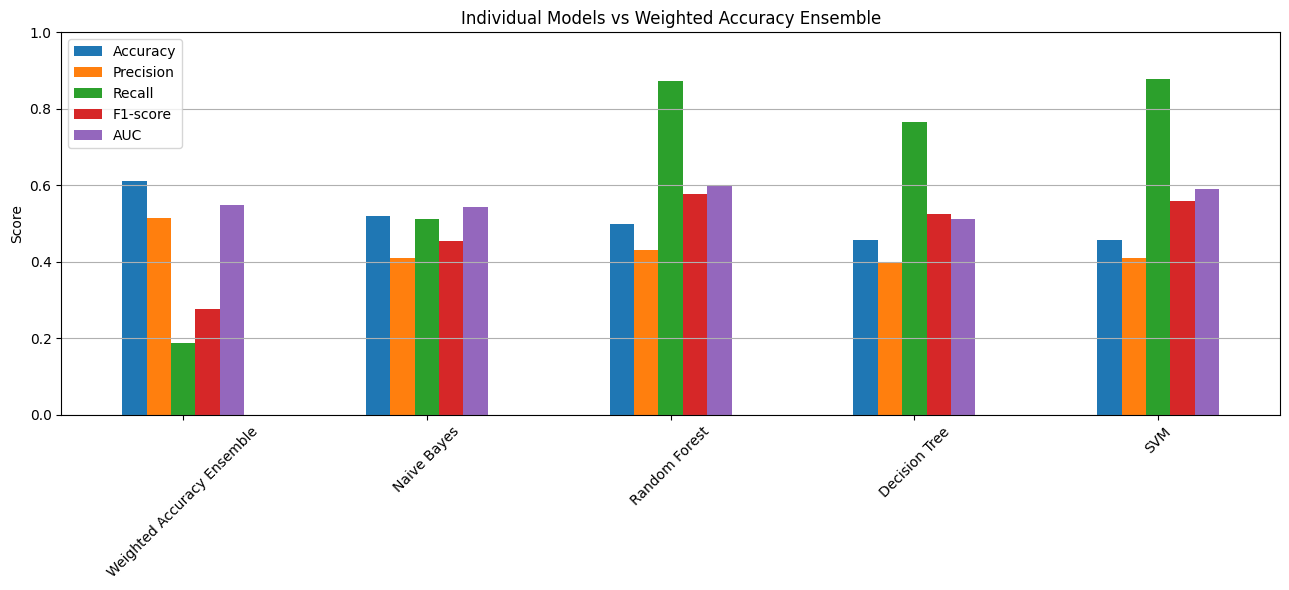

In [ ]:
# ============================================================
# 8. Bar chart comparison
# ============================================================

comparison_with_ensemble[["Accuracy", "Precision", "Recall", "F1-score", "AUC"]].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Individual Models vs Weighted Accuracy Ensemble")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

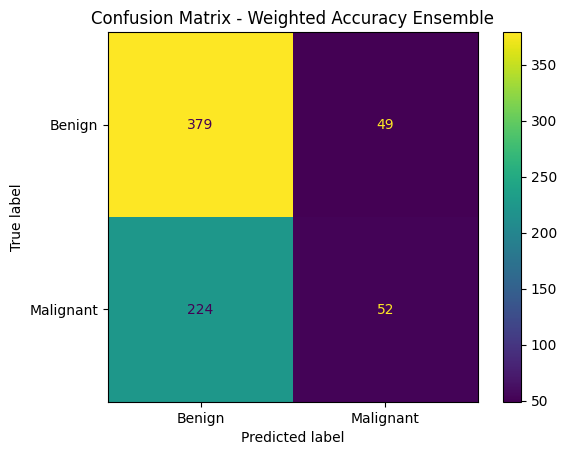

In [ ]:
# ============================================================
# 9. Ensemble confusion matrix
# ============================================================

cm = confusion_matrix(y_test, test_ensemble_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix - Weighted Accuracy Ensemble")
plt.show()

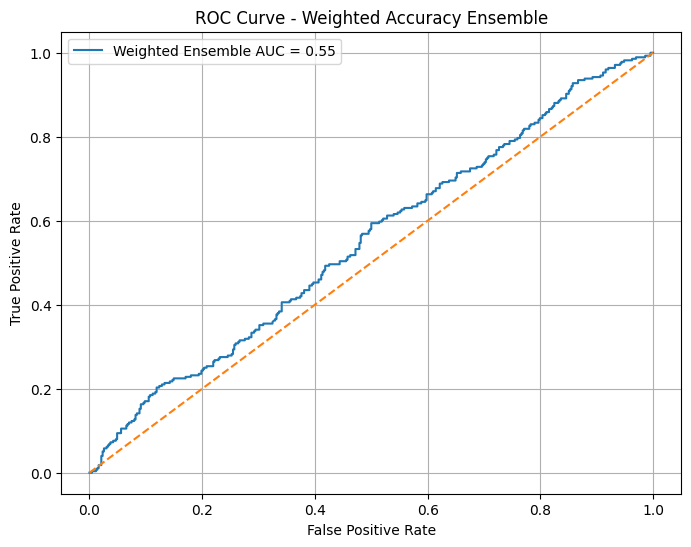

In [ ]:
# ============================================================
# 10. Ensemble ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, test_ensemble_scores)
ensemble_auc = roc_auc_score(y_test, test_ensemble_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Weighted Ensemble AUC = {ensemble_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Weighted Accuracy Ensemble")
plt.legend()
plt.grid()
plt.show()

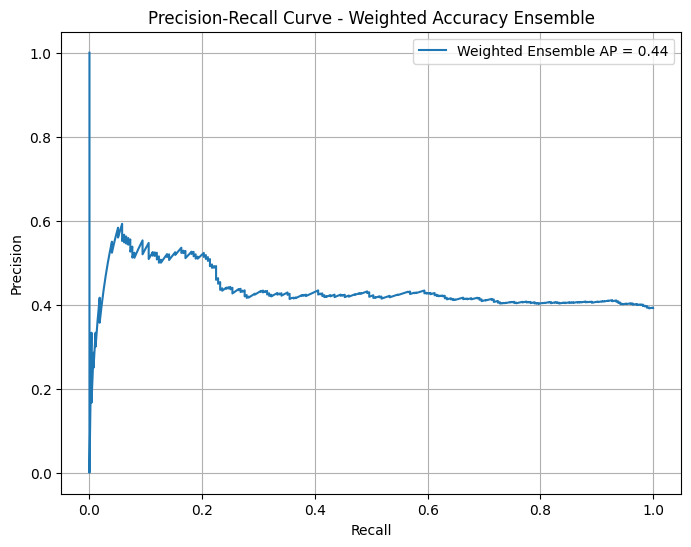

In [ ]:
# ============================================================
# 11. Ensemble Precision-Recall curve
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, test_ensemble_scores)
ap = average_precision_score(y_test, test_ensemble_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Weighted Ensemble AP = {ap:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Weighted Accuracy Ensemble")
plt.legend()
plt.grid()
plt.show()

Total Results: Individual Models + Weighted Accuracy Ensemble


,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Weighted Accuracy Ensemble,0.63,0.612216,0.514851,0.188406,0.275862,0.549027
Naive Bayes,0.10,0.518466,0.408696,0.510870,0.454106,0.544503
Random Forest,0.38,0.500000,0.431900,0.873188,0.577938,0.602029
Decision Tree,0.10,0.457386,0.399621,0.764493,0.524876,0.512448
SVM,0.32,0.455966,0.409475,0.876812,0.558247,0.589966



Best Model by Metric


,Model,Score
Best Accuracy,Weighted Accuracy Ensemble,0.612216
Best Precision,Weighted Accuracy Ensemble,0.514851
Best Recall,SVM,0.876812
Best F1-score,Random Forest,0.577938
Best AUC,Random Forest,0.602029



Overall Winner Based on Accuracy
Best model: Weighted Accuracy Ensemble
Accuracy: 0.6122


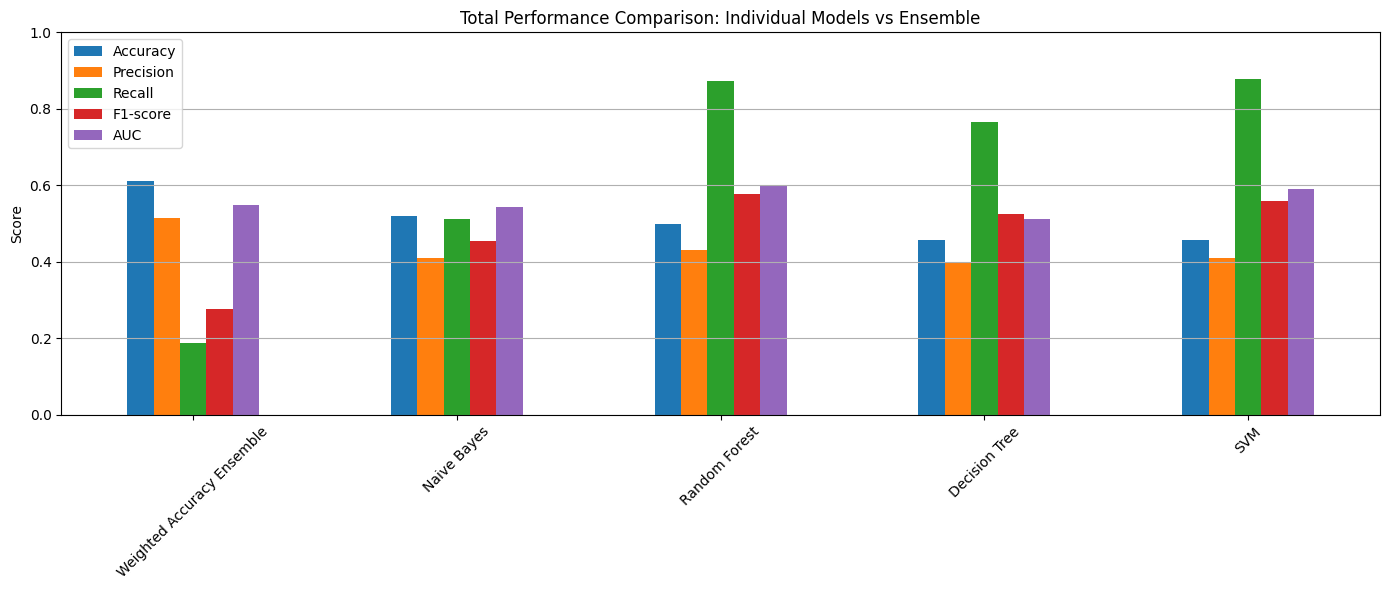

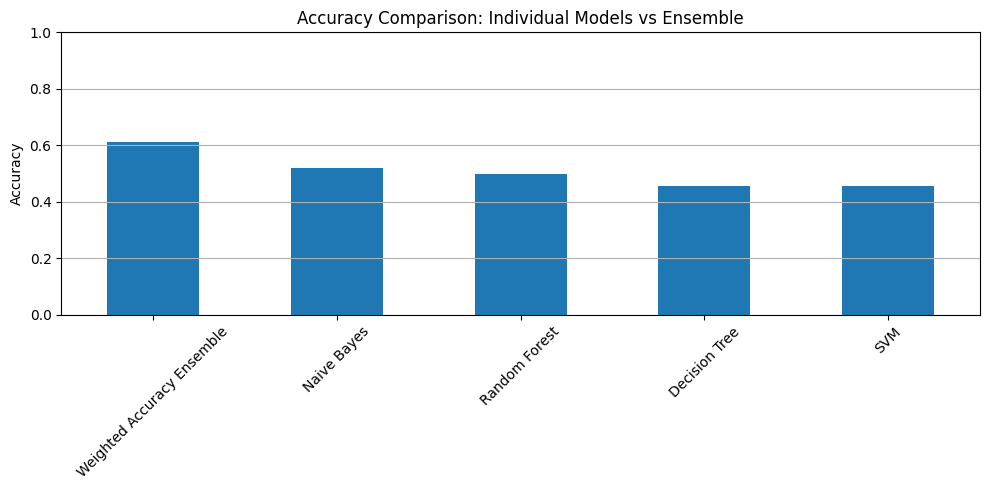

In [ ]:
# ============================================================
# 12. Total Results Summary
# ============================================================

# Combine individual model results with ensemble result
total_results_df = pd.concat([
    results_df,
    ensemble_results_df
])

# Keep only the important metric columns
metric_columns = [
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
]

total_results_df = total_results_df[metric_columns]

# Sort by Accuracy because your goal here is maximum accuracy
total_results_df = total_results_df.sort_values("Accuracy", ascending=False)

print("Total Results: Individual Models + Weighted Accuracy Ensemble")
display(total_results_df)


# ============================================================
# 13. Best Model by Each Metric
# ============================================================

best_summary = {
    "Best Accuracy": {
        "Model": total_results_df["Accuracy"].idxmax(),
        "Score": total_results_df["Accuracy"].max()
    },
    "Best Precision": {
        "Model": total_results_df["Precision"].idxmax(),
        "Score": total_results_df["Precision"].max()
    },
    "Best Recall": {
        "Model": total_results_df["Recall"].idxmax(),
        "Score": total_results_df["Recall"].max()
    },
    "Best F1-score": {
        "Model": total_results_df["F1-score"].idxmax(),
        "Score": total_results_df["F1-score"].max()
    },
    "Best AUC": {
        "Model": total_results_df["AUC"].idxmax(),
        "Score": total_results_df["AUC"].max()
    }
}

best_summary_df = pd.DataFrame(best_summary).T

print("\nBest Model by Metric")
display(best_summary_df)


# ============================================================
# 14. Overall Accuracy Winner
# ============================================================

accuracy_winner = total_results_df["Accuracy"].idxmax()
accuracy_score_value = total_results_df.loc[accuracy_winner, "Accuracy"]

print("\nOverall Winner Based on Accuracy")
print(f"Best model: {accuracy_winner}")
print(f"Accuracy: {accuracy_score_value:.4f}")


# ============================================================
# 15. Total Results Bar Chart
# ============================================================

total_results_df[["Accuracy", "Precision", "Recall", "F1-score", "AUC"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Total Performance Comparison: Individual Models vs Ensemble")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ============================================================
# 16. Accuracy-Only Bar Chart
# ============================================================

total_results_df[["Accuracy"]].plot(
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Accuracy Comparison: Individual Models vs Ensemble")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 12. Final Total Results Summary
# ============================================================

# Combine individual model results + ensemble result
total_results_df = pd.concat([
    results_df,
    ensemble_results_df
])

# Make sure all columns are numeric
total_results_df = total_results_df.apply(pd.to_numeric, errors="ignore")

# Sort by highest accuracy
total_results_df = total_results_df.sort_values("Accuracy", ascending=False)

# Round values for clean display
total_results_display = total_results_df.copy()
numeric_cols = ["Threshold", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]

for col in numeric_cols:
    if col in total_results_display.columns:
        total_results_display[col] = total_results_display[col].round(4)

print("Final Total Results: Individual Models vs Weighted Accuracy Ensemble")
display(total_results_display)

Final Total Results: Individual Models vs Weighted Accuracy Ensemble


/tmp/ipykernel_11472/3870862291.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  total_results_df = total_results_df.apply(pd.to_numeric, errors="ignore")


,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Weighted Accuracy Ensemble,0.63,0.6122,0.5149,0.1884,0.2759,0.5490
Naive Bayes,0.10,0.5185,0.4087,0.5109,0.4541,0.5445
Random Forest,0.38,0.5000,0.4319,0.8732,0.5779,0.6020
Decision Tree,0.10,0.4574,0.3996,0.7645,0.5249,0.5124
SVM,0.32,0.4560,0.4095,0.8768,0.5582,0.5900


In [ ]:
# ============================================================
# 17. Show Benign / Malignant Predictions
# ============================================================

prediction_labels_df = pd.DataFrame({
    "True Label Number": y_test,
    "Predicted Label Number": test_ensemble_preds,
    "Malignant Probability": test_ensemble_scores
})

prediction_labels_df["True Label"] = prediction_labels_df["True Label Number"].map({
    0: "Benign",
    1: "Malignant"
})

prediction_labels_df["Predicted Label"] = prediction_labels_df["Predicted Label Number"].map({
    0: "Benign",
    1: "Malignant"
})

prediction_labels_df["Correct Prediction"] = (
    prediction_labels_df["True Label Number"] == prediction_labels_df["Predicted Label Number"]
)

prediction_labels_df = prediction_labels_df[
    [
        "True Label",
        "Predicted Label",
        "Malignant Probability",
        "Correct Prediction"
    ]
]

display(prediction_labels_df.head(30))

,True Label,Predicted Label,Malignant Probability,Correct Prediction
0,Malignant,Benign,0.604983,False
1,Malignant,Benign,0.548426,False
2,Malignant,Benign,0.389323,False
3,Malignant,Benign,0.544846,False
4,Benign,Benign,0.457912,True
5,Benign,Benign,0.601839,True
6,Malignant,Malignant,0.656311,True
7,Malignant,Benign,0.465714,False
8,Benign,Benign,0.402790,True
9,Malignant,Benign,0.210291,False


,Predicted Class,Count
0,Benign,603
1,Malignant,101


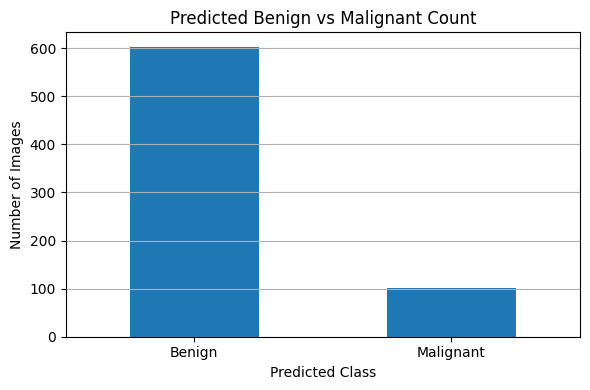

In [ ]:
# ============================================================
# 18. Count Benign / Malignant Predictions
# ============================================================

prediction_count_df = prediction_labels_df["Predicted Label"].value_counts().reset_index()
prediction_count_df.columns = ["Predicted Class", "Count"]

display(prediction_count_df)

prediction_count_df.plot(
    kind="bar",
    x="Predicted Class",
    y="Count",
    figsize=(6, 4),
    legend=False
)

plt.title("Predicted Benign vs Malignant Count")
plt.xlabel("Predicted Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Single Image Prediction
-----------------------
Prediction: Benign
Malignant Probability: 0.2902
Threshold: 0.63


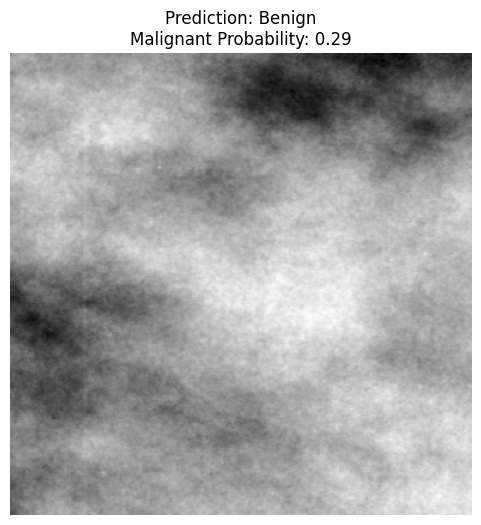

In [ ]:
# ============================================================
# Single Image Ensemble Prediction: Benign or Malignant
# ============================================================

import cv2

# Read uploaded image
image = cv2.imread(str(uploaded_image_path))

if image is None:
    raise ValueError("Could not load uploaded image.")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Resize based on feature mode
image_size = HOG_IMG_SIZE if FEATURE_MODE == "hog" else RAW_IMG_SIZE

gray_resized = cv2.resize(gray, (image_size, image_size))

# Extract features using your existing function
single_image_features = extract_features_from_gray(gray_resized).reshape(1, -1)

# Get ensemble malignant probability
single_image_scores = get_weighted_ensemble_scores(single_image_features)

# Convert probability to prediction
single_image_prediction = (
    single_image_scores >= best_threshold
).astype(int)[0]

single_image_label = (
    "Malignant"
    if single_image_prediction == 1
    else "Benign"
)

# Display result
print("Single Image Prediction")
print("-----------------------")
print("Prediction:", single_image_label)
print("Malignant Probability:", round(float(single_image_scores[0]), 4))
print("Threshold:", round(float(best_threshold), 4))

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title(
    f"Prediction: {single_image_label}\n"
    f"Malignant Probability: {float(single_image_scores[0]):.2f}"
)
plt.axis("off")
plt.show()

Augmented image folders created:
/content/augmented_cbis_ddsm/generated/benign
/content/augmented_cbis_ddsm/generated/malignant


100%|██████████| 1181/1181 [00:13<00:00, 85.94it/s]


Benign images for VAE: (1682, 64, 64, 1)
Malignant images for VAE: (1181, 64, 64, 1)
Training Benign VAE...
Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - kl_loss: 17.0769 - loss: 2116.3638 - reconstruction_loss: 2099.2871
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 13.1138 - loss: 1822.1497 - reconstruction_loss: 1809.0363
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 10.9932 - loss: 1812.9987 - reconstruction_loss: 1802.0057
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 10.7978 - loss: 1808.6029 - reconstruction_loss: 1797.8046
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 10.8569 - loss: 1807.0560 - reconstruction_loss: 1796.1992
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 10.3731 - loss: 1801.9833 - reconstruction_loss: 1791.6101
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 10.6227 - loss: 1800.2518 - reconstruction_loss: 1789.6298
Epoch 8/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

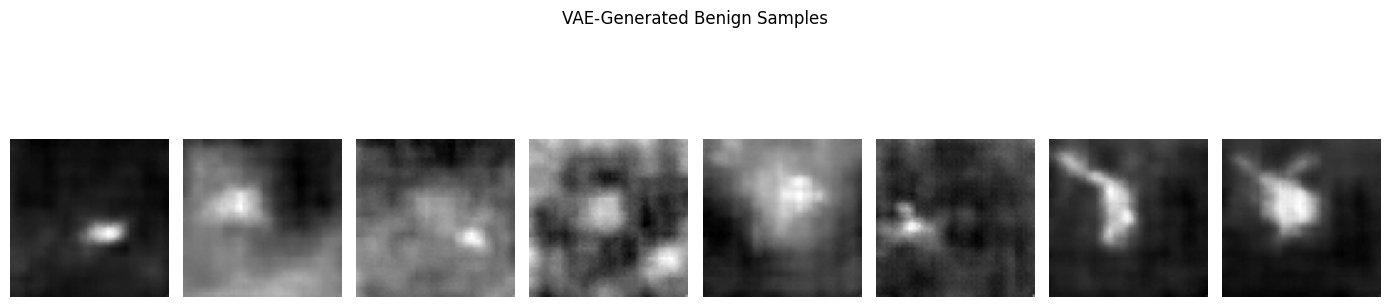

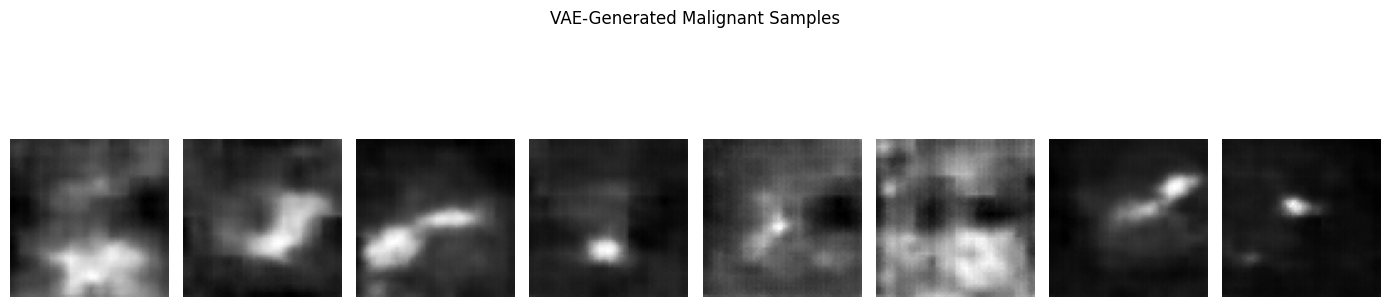

Original training size: 2863
Generated images: 600
Augmented training size: 3463

Augmented label distribution:
label
0    1982
1    1481
Name: count, dtype: int64

Augmented case type distribution:
case_type
calcification    1545
mass             1318
generated_vae     600
Name: count, dtype: int64


In [40]:
# ============================================================
# 25. Generative AI Augmentation using VAE
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model

np.random.seed(42)
tf.random.set_seed(42)

# VAE configuration
VAE_IMG_SIZE = 64
LATENT_DIM = 32
VAE_EPOCHS = 40
VAE_BATCH_SIZE = 32

# Number of synthetic images to generate per class
N_BENIGN_GENERATED = 300
N_MALIGNANT_GENERATED = 300

# Output folders
AUGMENTED_DIR = Path("/content/augmented_cbis_ddsm")
BENIGN_GEN_DIR = AUGMENTED_DIR / "generated" / "benign"
MALIGNANT_GEN_DIR = AUGMENTED_DIR / "generated" / "malignant"

BENIGN_GEN_DIR.mkdir(parents=True, exist_ok=True)
MALIGNANT_GEN_DIR.mkdir(parents=True, exist_ok=True)

print("Augmented image folders created:")
print(BENIGN_GEN_DIR)
print(MALIGNANT_GEN_DIR)


# ============================================================
# 26. Prepare Images for VAE Training
# ============================================================

def load_image_for_vae(image_path, img_size=VAE_IMG_SIZE):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    image = cv2.resize(image, (img_size, img_size))

    # CLAHE improves local contrast in mammogram images
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    image = clahe.apply(image)

    image = image.astype("float32") / 255.0
    image = np.expand_dims(image, axis=-1)

    return image


def build_vae_training_array(df, label_value):
    images = []
    class_df = df[df["label"] == label_value]

    for _, row in tqdm(class_df.iterrows(), total=len(class_df)):
        img = load_image_for_vae(row["matched_image_path"])

        if img is not None:
            images.append(img)

    return np.array(images, dtype="float32")


benign_images = build_vae_training_array(train_clean, label_value=0)
malignant_images = build_vae_training_array(train_clean, label_value=1)

print("Benign images for VAE:", benign_images.shape)
print("Malignant images for VAE:", malignant_images.shape)


# ============================================================
# 27. Build VAE Model
# ============================================================

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_encoder(img_size=VAE_IMG_SIZE, latent_dim=LATENT_DIM):
    encoder_inputs = layers.Input(shape=(img_size, img_size, 1))

    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="encoder"
    )

    return encoder


def build_decoder(img_size=VAE_IMG_SIZE, latent_dim=LATENT_DIM):
    latent_inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 128))(x)

    x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

    decoder_outputs = layers.Conv2DTranspose(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    decoder = Model(
        latent_inputs,
        decoder_outputs,
        name="decoder"
    )

    return decoder


class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


def create_vae():
    encoder = build_encoder()
    decoder = build_decoder()

    vae = VAE(encoder, decoder)
    vae.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    )

    return vae, encoder, decoder


# ============================================================
# 28. Train Separate VAE Models for Benign and Malignant
# ============================================================

benign_vae, benign_encoder, benign_decoder = create_vae()

print("Training Benign VAE...")
benign_history = benign_vae.fit(
    benign_images,
    epochs=VAE_EPOCHS,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True
)

malignant_vae, malignant_encoder, malignant_decoder = create_vae()

print("Training Malignant VAE...")
malignant_history = malignant_vae.fit(
    malignant_images,
    epochs=VAE_EPOCHS,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True
)


# ============================================================
# 29. Generate Synthetic Images
# ============================================================

def clear_existing_generated_images(folder):
    for file_path in folder.glob("*.png"):
        file_path.unlink()


clear_existing_generated_images(BENIGN_GEN_DIR)
clear_existing_generated_images(MALIGNANT_GEN_DIR)


def generate_synthetic_images(decoder, output_dir, class_name, n_images):
    generated_paths = []

    for i in range(n_images):
        z_sample = np.random.normal(size=(1, LATENT_DIM))
        generated = decoder.predict(z_sample, verbose=0)[0]

        generated = np.squeeze(generated)
        generated = np.clip(generated * 255, 0, 255).astype(np.uint8)

        output_path = output_dir / f"{class_name}_generated_{i:04d}.png"
        cv2.imwrite(str(output_path), generated)

        generated_paths.append(str(output_path))

    return generated_paths


benign_generated_paths = generate_synthetic_images(
    decoder=benign_decoder,
    output_dir=BENIGN_GEN_DIR,
    class_name="benign",
    n_images=N_BENIGN_GENERATED
)

malignant_generated_paths = generate_synthetic_images(
    decoder=malignant_decoder,
    output_dir=MALIGNANT_GEN_DIR,
    class_name="malignant",
    n_images=N_MALIGNANT_GENERATED
)

print("Generated benign images:", len(benign_generated_paths))
print("Generated malignant images:", len(malignant_generated_paths))


# ============================================================
# 30. Show Generated Image Samples
# ============================================================

def show_generated_samples(image_paths, title, n=8):
    sample_paths = image_paths[:n]

    plt.figure(figsize=(14, 4))

    for i, path in enumerate(sample_paths):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_generated_samples(
    benign_generated_paths,
    title="VAE-Generated Benign Samples",
    n=8
)

show_generated_samples(
    malignant_generated_paths,
    title="VAE-Generated Malignant Samples",
    n=8
)


# ============================================================
# 31. Create Augmented Training Dataset for Model-B
# ============================================================

benign_aug_df = pd.DataFrame({
    "matched_image_path": benign_generated_paths,
    "label": 0,
    "pathology": "BENIGN_GENERATED",
    "case_type": "generated_vae"
})

malignant_aug_df = pd.DataFrame({
    "matched_image_path": malignant_generated_paths,
    "label": 1,
    "pathology": "MALIGNANT_GENERATED",
    "case_type": "generated_vae"
})

generated_train_df = pd.concat(
    [benign_aug_df, malignant_aug_df],
    ignore_index=True
)

train_augmented_clean = pd.concat(
    [
        train_clean[["matched_image_path", "label", "pathology", "case_type"]],
        generated_train_df
    ],
    ignore_index=True
)

print("Original training size:", len(train_clean))
print("Generated images:", len(generated_train_df))
print("Augmented training size:", len(train_augmented_clean))

print("\nAugmented label distribution:")
print(train_augmented_clean["label"].value_counts())

print("\nAugmented case type distribution:")
print(train_augmented_clean["case_type"].value_counts())

In [41]:
# ============================================================
# 32. Build Features for Model-B: Augmented Training Data
# ============================================================

print("Building Model-B augmented training features...")

X_train_B, y_train_B = build_feature_dataset(train_augmented_clean)

print("Model-B X_train shape:", X_train_B.shape)
print("Model-B y_train shape:", y_train_B.shape)

print("\nModel-B label distribution:")
print(pd.Series(y_train_B).value_counts())

Building Model-B augmented training features...


100%|██████████| 3463/3463 [00:48<00:00, 71.19it/s] 

Model-B X_train shape: (3463, 1764)
Model-B y_train shape: (3463,)

Model-B label distribution:
0    1982
1    1481
Name: count, dtype: int64


In [42]:
# ============================================================
# 33. Split Model-B Augmented Data into Train and Validation
# ============================================================

from sklearn.model_selection import train_test_split

X_train_B_final, X_val_B, y_train_B_final, y_val_B = train_test_split(
    X_train_B,
    y_train_B,
    test_size=0.2,
    random_state=42,
    stratify=y_train_B
)

print("Model-B train:", X_train_B_final.shape)
print("Model-B validation:", X_val_B.shape)
print("Original test remains:", X_test.shape)

Model-B train: (2770, 1764)
Model-B validation: (693, 1764)
Original test remains: (704, 1764)


In [43]:
# ============================================================
# 34. Train Model-B on Augmented Data
# ============================================================

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models_B = {
    "SVM": SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": GaussianNB(
        var_smoothing=1e-8
    )
}

for name, model in models_B.items():
    print(f"Training Model-B {name}...")
    model.fit(X_train_B_final, y_train_B_final)
    print(f"Model-B {name} trained successfully.")

Training Model-B SVM...
Model-B SVM trained successfully.
Training Model-B Decision Tree...
Model-B Decision Tree trained successfully.
Training Model-B Random Forest...
Model-B Random Forest trained successfully.
Training Model-B Naive Bayes...
Model-B Naive Bayes trained successfully.


In [44]:
# ============================================================
# 35. Tune Model-B Thresholds Using Validation Set
# ============================================================

from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold_for_f1(model, X_val, y_val):
    scores = get_positive_scores(model, X_val)

    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.05, 0.95, 0.01):
        preds = (scores >= threshold).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1


thresholds_B = {}

for name, model in models_B.items():
    best_threshold, best_f1 = find_best_threshold_for_f1(
        model,
        X_val_B,
        y_val_B
    )

    thresholds_B[name] = best_threshold

    print(f"{name}: Best Threshold = {best_threshold:.2f}, Validation F1 = {best_f1:.4f}")

SVM: Best Threshold = 0.30, Validation F1 = 0.6398
Decision Tree: Best Threshold = 0.07, Validation F1 = 0.5707
Random Forest: Best Threshold = 0.43, Validation F1 = 0.6361
Naive Bayes: Best Threshold = 0.05, Validation F1 = 0.4757


In [45]:
# ============================================================
# 36. Evaluate Model-B on Original Test Set
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model_with_threshold(model, X, y, threshold=0.5):
    scores = get_positive_scores(model, X)
    preds = (scores >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision_score(y, preds, zero_division=0),
        "Recall": recall_score(y, preds, zero_division=0),
        "F1-score": f1_score(y, preds, zero_division=0),
        "AUC": roc_auc_score(y, scores)
    }


results_B = {}

for name, model in models_B.items():
    results_B[name] = evaluate_model_with_threshold(
        model,
        X_test,
        y_test,
        thresholds_B[name]
    )

results_B_df = pd.DataFrame(results_B).T.sort_values("F1-score", ascending=False)

print("Model-B Results: Augmented Data")
display(results_B_df)

Model-B Results: Augmented Data


,Threshold,Accuracy,Precision,Recall,F1-score,AUC
SVM,0.30,0.446023,0.403716,0.865942,0.550691,0.573945
Decision Tree,0.07,0.455966,0.404973,0.826087,0.543504,0.529392
Random Forest,0.43,0.524148,0.433107,0.692029,0.532775,0.587689
Naive Bayes,0.05,0.518466,0.408696,0.510870,0.454106,0.515026


In [46]:
# ============================================================
# 37. Compare Model-A vs Model-B
# ============================================================

model_A_results = results_df.copy()
model_B_results = results_B_df.copy()

model_A_results["Experiment"] = "Model-A Original Data"
model_B_results["Experiment"] = "Model-B VAE Augmented Data"

model_A_results["Model"] = model_A_results.index
model_B_results["Model"] = model_B_results.index

comparison_A_B = pd.concat(
    [model_A_results, model_B_results],
    axis=0
)

comparison_A_B = comparison_A_B[
    [
        "Experiment",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ]
]

comparison_A_B = comparison_A_B.sort_values(
    ["Model", "Experiment"]
)

display(comparison_A_B)

,Experiment,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
Decision Tree,Model-A Original Data,Decision Tree,0.10,0.457386,0.399621,0.764493,0.524876,0.512448
Decision Tree,Model-B VAE Augmented Data,Decision Tree,0.07,0.455966,0.404973,0.826087,0.543504,0.529392
Naive Bayes,Model-A Original Data,Naive Bayes,0.10,0.518466,0.408696,0.510870,0.454106,0.544503
Naive Bayes,Model-B VAE Augmented Data,Naive Bayes,0.05,0.518466,0.408696,0.510870,0.454106,0.515026
Random Forest,Model-A Original Data,Random Forest,0.38,0.500000,0.431900,0.873188,0.577938,0.602029
Random Forest,Model-B VAE Augmented Data,Random Forest,0.43,0.524148,0.433107,0.692029,0.532775,0.587689
SVM,Model-A Original Data,SVM,0.32,0.455966,0.409475,0.876812,0.558247,0.589966
SVM,Model-B VAE Augmented Data,SVM,0.30,0.446023,0.403716,0.865942,0.550691,0.573945


In [47]:
# ============================================================
# 38. Calculate Improvement from Model-A to Model-B
# ============================================================

improvement_rows = []

for model_name in model_A_results["Model"].unique():
    A = model_A_results[model_A_results["Model"] == model_name].iloc[0]
    B = model_B_results[model_B_results["Model"] == model_name].iloc[0]

    improvement_rows.append({
        "Model": model_name,
        "Accuracy Change": B["Accuracy"] - A["Accuracy"],
        "Precision Change": B["Precision"] - A["Precision"],
        "Recall Change": B["Recall"] - A["Recall"],
        "F1-score Change": B["F1-score"] - A["F1-score"],
        "AUC Change": B["AUC"] - A["AUC"]
    })

improvement_df = pd.DataFrame(improvement_rows)

print("Improvement from Model-A to Model-B")
display(improvement_df)

Improvement from Model-A to Model-B


,Model,Accuracy Change,Precision Change,Recall Change,F1-score Change,AUC Change
0,Random Forest,0.024148,0.001207,-0.181159,-0.045162,-0.014340
1,SVM,-0.009943,-0.005759,-0.010870,-0.007556,-0.016021
2,Decision Tree,-0.001420,0.005352,0.061594,0.018629,0.016943
3,Naive Bayes,0.000000,0.000000,0.000000,0.000000,-0.029477


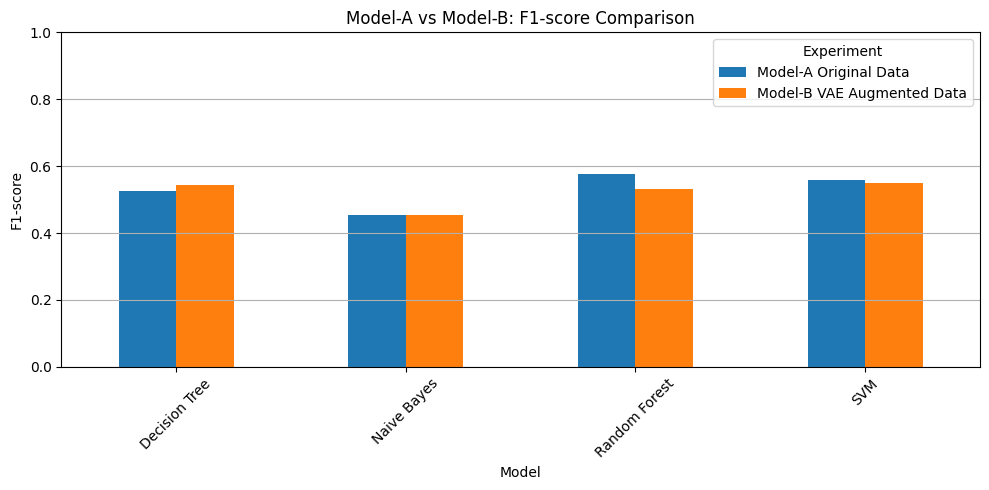

In [50]:
# ============================================================
# 39. Model-A vs Model-B F1-score Comparison
# ============================================================

import matplotlib.pyplot as plt

plot_df = comparison_A_B.pivot(
    index="Model",
    columns="Experiment",
    values="F1-score"
)

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Model-A vs Model-B: F1-score Comparison")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

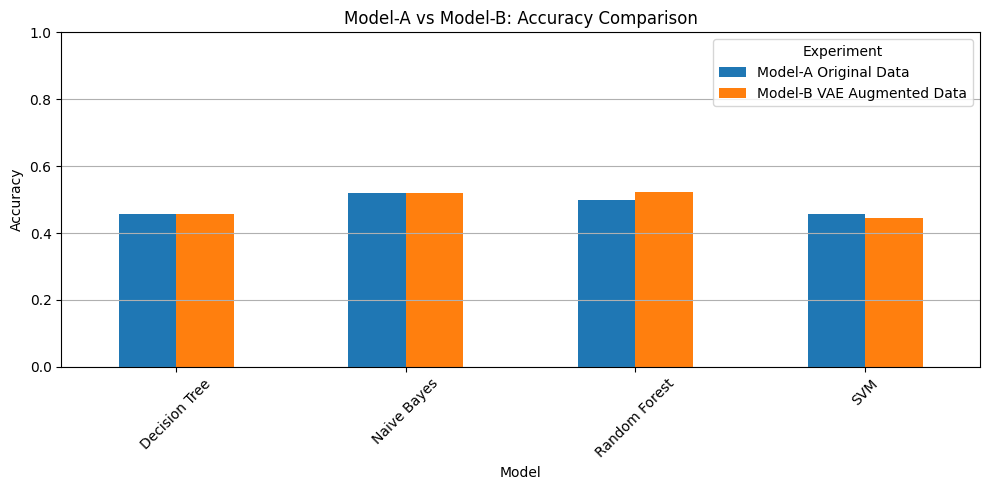

In [49]:
# ============================================================
# 40. Model-A vs Model-B Accuracy Comparison
# ============================================================

plot_df = comparison_A_B.pivot(
    index="Model",
    columns="Experiment",
    values="Accuracy"
)

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Model-A vs Model-B: Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# 41. Best Model Summary: Model-A vs Model-B
# ============================================================

best_summary = []

for metric in ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]:
    best_row = comparison_A_B.loc[comparison_A_B[metric].idxmax()]

    best_summary.append({
        "Metric": metric,
        "Best Experiment": best_row["Experiment"],
        "Best Model": best_row["Model"],
        "Best Score": best_row[metric]
    })

best_summary_df = pd.DataFrame(best_summary)

display(best_summary_df)

,Metric,Best Experiment,Best Model,Best Score
0,Accuracy,Random Forest Model-A Original Data Ra...,Random Forest Random Forest Random Forest ...,Random Forest 0.500000 Random Forest 0.5...
1,Precision,Random Forest Model-A Original Data Ra...,Random Forest Random Forest Random Forest ...,Random Forest 0.431900 Random Forest 0.4...
2,Recall,SVM Model-A Original Data SVM Model...,"SVM SVM SVM SVM Name: Model, dtype: object","SVM 0.876812 SVM 0.865942 Name: Recall, ..."
3,F1-score,Random Forest Model-A Original Data Ra...,Random Forest Random Forest Random Forest ...,Random Forest 0.577938 Random Forest 0.5...
4,AUC,Random Forest Model-A Original Data Ra...,Random Forest Random Forest Random Forest ...,Random Forest 0.602029 Random Forest 0.5...


In [53]:
import pandas as pd

# ============================================================
# 42. Auto-Generated Conclusion Summary
# ============================================================

# Re-create best_summary_df correctly, as the previous one contained Series as values.
# comparison_A_B DataFrame is available from the kernel state.
best_summary = []

for metric in ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]:
    # Sort by the current metric in descending order and get the first row
    # This ensures best_row_series is a single pandas Series with scalar values
    best_row_series = comparison_A_B.sort_values(by=metric, ascending=False).iloc[0]

    best_summary.append({
        "Metric": metric,
        "Best Experiment": best_row_series["Experiment"],
        "Best Model": best_row_series["Model"],
        "Best Score": best_row_series[metric]
    })

best_summary_df = pd.DataFrame(best_summary)

best_accuracy = best_summary_df[best_summary_df["Metric"] == "Accuracy"].iloc[0]
best_f1 = best_summary_df[best_summary_df["Metric"] == "F1-score"].iloc[0]
best_recall = best_summary_df[best_summary_df["Metric"] == "Recall"].iloc[0]
best_auc = best_summary_df[best_summary_df["Metric"] == "AUC"].iloc[0]

print("Final Project Findings")
print("----------------------")
print(f"Best Accuracy: {best_accuracy['Best Model']} ({best_accuracy['Best Experiment']}) = {best_accuracy['Best Score']:.4f}")
print(f"Best F1-score: {best_f1['Best Model']} ({best_f1['Best Experiment']}) = {best_f1['Best Score']:.4f}")
print(f"Best Recall: {best_recall['Best Model']} ({best_recall['Best Experiment']}) = {best_recall['Best Score']:.4f}")
print(f"Best AUC: {best_auc['Best Model']} ({best_auc['Best Experiment']}) = {best_auc['Best Score']:.4f}")

print("\nInterpretation:")
print("VAE-based augmentation showed a mixed impact. Some models improved in selected metrics, especially Decision Tree recall and F1-score, while other models showed limited or reduced performance. This suggests that the quality and usefulness of synthetic VAE images varies depending on the classifier.")

Final Project Findings
----------------------
Best Accuracy: Random Forest (Model-B VAE Augmented Data) = 0.5241
Best F1-score: Random Forest (Model-A Original Data) = 0.5779
Best Recall: SVM (Model-A Original Data) = 0.8768
Best AUC: Random Forest (Model-A Original Data) = 0.6020

Interpretation:
VAE-based augmentation showed a mixed impact. Some models improved in selected metrics, especially Decision Tree recall and F1-score, while other models showed limited or reduced performance. This suggests that the quality and usefulness of synthetic VAE images varies depending on the classifier.


In [54]:
# ============================================================
# 43. Save Final Results
# ============================================================

comparison_A_B.to_csv("/content/model_a_vs_model_b_results.csv", index=False)
improvement_df.to_csv("/content/model_b_improvement.csv", index=False)
best_summary_df.to_csv("/content/best_model_summary.csv", index=False)

print("Saved:")
print("/content/model_a_vs_model_b_results.csv")
print("/content/model_b_improvement.csv")
print("/content/best_model_summary.csv")

Saved:
/content/model_a_vs_model_b_results.csv
/content/model_b_improvement.csv
/content/best_model_summary.csv


In [57]:
import shutil
from pathlib import Path

export_dir = Path("/content/github_export")
results_dir = export_dir / "results"
augmented_dir = export_dir / "augmented_images"

# Create folders
results_dir.mkdir(parents=True, exist_ok=True)
(augmented_dir / "benign").mkdir(parents=True, exist_ok=True)
(augmented_dir / "malignant").mkdir(parents=True, exist_ok=True)

# Copy result CSV files
result_files = [
    "model_a_vs_model_b_results.csv",
    "model_b_improvement.csv",
    "best_model_summary.csv"
]

for file_name in result_files:
    shutil.copy(
        f"/content/{file_name}",
        results_dir / file_name
    )

# Copy augmented images
benign_source = Path("/content/augmented_cbis_ddsm/generated/benign")
malignant_source = Path("/content/augmented_cbis_ddsm/generated/malignant")

for img in benign_source.glob("*.png"):
    shutil.copy(img, augmented_dir / "benign" / img.name)

for img in malignant_source.glob("*.png"):
    shutil.copy(img, augmented_dir / "malignant" / img.name)

# Zip everything
zip_path = shutil.make_archive("/content/github_export", "zip", export_dir)

print("Created:", zip_path)
files.download("/content/github_export.zip")

Created: /content/github_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

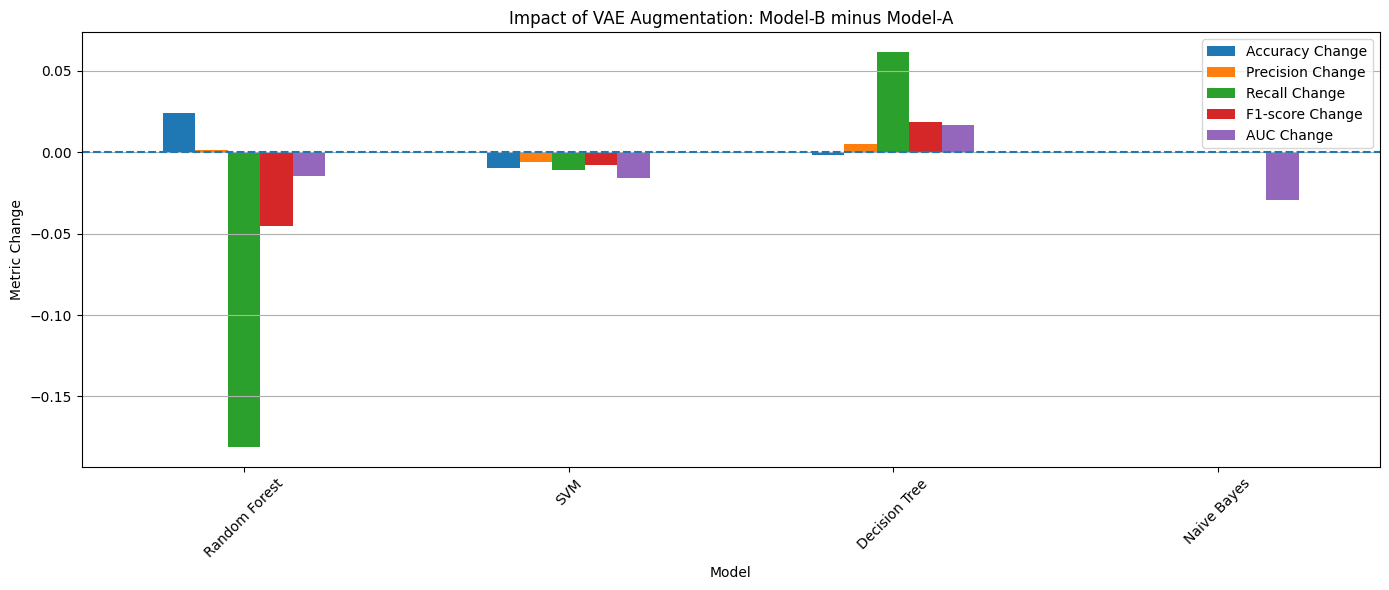

In [55]:
# ============================================================
# 44. Augmentation Impact Chart
# ============================================================

impact_plot_df = improvement_df.set_index("Model")[
    [
        "Accuracy Change",
        "Precision Change",
        "Recall Change",
        "F1-score Change",
        "AUC Change"
    ]
]

impact_plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.axhline(0, linestyle="--")
plt.title("Impact of VAE Augmentation: Model-B minus Model-A")
plt.ylabel("Metric Change")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# final conclusion
This project evaluated the impact of VAE-based generative augmentation on CBIS-DDSM breast cancer classification. Model-A was trained using the original dataset, while Model-B was trained using the original data plus VAE-generated benign and malignant images.

The results showed a mixed impact. Decision Tree improved in recall, F1-score, and AUC after augmentation, while Random Forest achieved higher accuracy. However, augmentation did not consistently improve all classifiers. SVM and Random Forest showed lower F1-score after augmentation.

Overall, VAE augmentation increased the diversity of the training set, but its benefit was limited by the quality of generated images and the use of traditional ML classifiers. Future work could use CNN-based classifiers or more advanced generative models such as GANs or diffusion models.